# Analytic Dataset for ICU Patient Clustering

This notebook creates an initial analytic dataset from the processed eICU tables.

The final dataset contains one row for each eligible ICU stay and one column for each eligible ICU stay and one column for each selected clustering variable.

The notebook performs the following work :
- Defines the study population
- Applies inclusion and exclusion criteria
- Uses the first 24 hours of the ICU stay
- Extracts the selected clinical variables
- Merges the variables into one table
- Examines implausible values
- Calculates descriptive statistics
- Calculates missingness
- Applies median imputation
- Identifies skewed variables
- Applies suitable transformations
- Standardizes the variables for KMeans
- Saves the final analytic dataset and clustering matrix

### Import Required Libraries

In [1]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#### Explanation :
These libraries are used for :
- `Path`: working with project folders and file paths
- `Counter`: counting implausible values
- `re`: cleaning file and laboratory names
- `NumPy`: numerical calculations and transformations
- `Pandas`: reading, cleaning, merging, and saving datasets
- `Matplotlib` and `Seaborn`: creating plots
- `SimpleImputer`: replacing missing values
- `StandardScaler`: standardizing variables before K-Means

### Setting the Propject Folder Paths

In [2]:
# Get the folder from which the notebook is currently running
CURRENT_DIR = Path.cwd().resolve()


# Find the root folder of the project
if (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "notebooks").exists():
    # The notebook is being run from the project root
    ROOT_DIR = CURRENT_DIR

elif CURRENT_DIR.name == "module_2" and CURRENT_DIR.parent.name == "notebooks":
    # The notebook is being run from notebooks/module_2
    ROOT_DIR = CURRENT_DIR.parents[1]

elif CURRENT_DIR.name == "notebooks":
    # The notebook is being run from the notebooks folder
    ROOT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "The project root folder could not be found. "
        "Run the notebook from the project root, notebooks, "
        "or notebooks/module_2 folder."
    )


# Input folder containing the processed eICU CSV tables
PROCESSED_DIR = ROOT_DIR / "data" / "processed"


# Main output folders
DATA_DIR = ROOT_DIR / "data"
PLOTS_DIR = ROOT_DIR / "plots" / "analytic_dataset"
RESULTS_DIR = ROOT_DIR / "results" / "analytic_dataset"


# Separate folders for different types of plots
DISTRIBUTION_PLOTS_DIR = PLOTS_DIR / "distributions"
MISSINGNESS_PLOTS_DIR = PLOTS_DIR / "missingness"
CORRELATION_PLOTS_DIR = PLOTS_DIR / "correlation"
TRANSFORMATION_PLOTS_DIR = PLOTS_DIR / "transformations"


# Final dataset paths
ANALYTIC_DATASET_PATH = DATA_DIR / "analytic_dataset.csv"

CLUSTERING_MATRIX_PATH = (
    DATA_DIR / "clustering_matrix_standardized.csv"
)


# Create all required output folders
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DISTRIBUTION_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MISSINGNESS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CORRELATION_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TRANSFORMATION_PLOTS_DIR.mkdir(parents=True, exist_ok=True)


print("=" * 100)
print("PROJECT FOLDER PATHS")
print("=" * 100)
print(f"Project root              : {ROOT_DIR}")
print(f"Processed eICU tables     : {PROCESSED_DIR}")
print(f"Analytic dataset plots    : {PLOTS_DIR}")
print(f"Analytic dataset results  : {RESULTS_DIR}")
print(f"Final analytic dataset    : {ANALYTIC_DATASET_PATH}")
print(f"Standardized matrix       : {CLUSTERING_MATRIX_PATH}")
print("=" * 100)

PROJECT FOLDER PATHS
Project root              : C:\Users\samsa\Documents\Capstone Project\Project
Processed eICU tables     : C:\Users\samsa\Documents\Capstone Project\Project\data\processed
Analytic dataset plots    : C:\Users\samsa\Documents\Capstone Project\Project\plots\analytic_dataset
Analytic dataset results  : C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset
Final analytic dataset    : C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv
Standardized matrix       : C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv


#### Explanation :
This code identifies the root folder regardless of whether the notebook is started from:
```
project_root/
project_root/notebooks/
```
or:
```
project_root/notebooks/module_2/
```
It creates the necessary output folders but does not create or use a raw-data folder.

### Define the Analysis Settings

In [3]:
# Identifier representing one ICU stay
ID_COLUMN = "patientunitstayid"


# First 24-hour measurement window
WINDOW_START_MINUTES = 0
WINDOW_END_MINUTES = 24 * 60


# Read large tables in smaller parts
CHUNK_SIZE = 500_000


# Require the ICU stay to last for the complete 24-hour window
REQUIRE_COMPLETE_24_HOURS = True


# Minimum number of available variables required before imputation
MINIMUM_OBSERVED_FEATURES = 10


# Threshold used to identify highly skewed variables
SKEWNESS_THRESHOLD = 1.0


# Missingness level that will produce a warning
MISSINGNESS_WARNING_PERCENT = 50.0


# Random seed for reproducible sampling and plots
RANDOM_STATE = 42


# Final clustering variables
FEATURES = [
    "age",
    "heart_rate",
    "mean_arterial_pressure",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "gcs",
    "urine_output",
    "wbc",
    "hemoglobin",
    "platelets",
    "sodium",
    "potassium",
    "bicarbonate",
    "creatinine",
    "glucose",
    "lactate",
    "total_bilirubin",
    "albumin",
    "inr",
]


print(f"Number of clustering variables: {len(FEATURES)}")

for number, feature in enumerate(FEATURES, start=1):
    print(f"{number:2d}. {feature}")

Number of clustering variables: 20
 1. age
 2. heart_rate
 3. mean_arterial_pressure
 4. respiratory_rate
 5. oxygen_saturation
 6. temperature
 7. gcs
 8. urine_output
 9. wbc
10. hemoglobin
11. platelets
12. sodium
13. potassium
14. bicarbonate
15. creatinine
16. glucose
17. lactate
18. total_bilirubin
19. albumin
20. inr


#### Explanation :
This section defines the rules used throughout the notebook.

The measurement window is:
```
0 to 1,440 minutes after ICU admission
```
The large eICU tables are read in chunks of $500,000$ rows. This reduces the risk of exhausting the computer's memory.

An ICU stay must initially contain at least $10$ of the $20$ features before missing values are imputed.

### Define Broad Data-Quality Ranges

In [4]:
# These are broad initial ranges used to identify likely recording errors.
# They are intentionally wider than normal clinical reference ranges.

PLAUSIBLE_RANGES = {
    "age": (18, 100),
    "heart_rate": (20, 250),
    "mean_arterial_pressure": (20, 200),
    "respiratory_rate": (4, 80),
    "oxygen_saturation": (50, 100),
    "temperature": (25, 45),
    "gcs": (3, 15),
    "urine_output": (0, 20_000),
    "wbc": (0.1, 200),
    "hemoglobin": (2, 25),
    "platelets": (1, 2_000),
    "sodium": (90, 200),
    "potassium": (1, 10),
    "bicarbonate": (2, 60),
    "creatinine": (0.1, 30),
    "glucose": (20, 2_000),
    "lactate": (0.1, 30),
    "total_bilirubin": (0.1, 50),
    "albumin": (0.5, 6),
    "inr": (0.5, 20),
}


plausible_ranges_table = pd.DataFrame(
    [
        {
            "variable": variable,
            "minimum_allowed": limits[0],
            "maximum_allowed": limits[1],
        }
        for variable, limits in PLAUSIBLE_RANGES.items()
    ]
)


plausible_ranges_table.to_csv(
    RESULTS_DIR / "plausible_value_ranges.csv",
    index=False,
)


plausible_ranges_table

,variable,minimum_allowed,maximum_allowed
0,age,18.0,100
1,heart_rate,20.0,250
2,mean_arterial_pressure,20.0,200
3,respiratory_rate,4.0,80
4,oxygen_saturation,50.0,100
5,temperature,25.0,45
6,gcs,3.0,15
7,urine_output,0.0,20000
8,wbc,0.1,200
9,hemoglobin,2.0,25


#### Explanation :
These ranges are used to find likely data errors.

They are not normal reference ranges. They are broad limits intended to remove values that are probably caused by:

- Data-entry errors
- Incorrect units
- Monitor errors
- Corrupted values

A clinically extreme value can still remain in the dataset when it falls inside these broad limits.

The ranges should be reviewed with the project advisor before final publication.

### Find the Processed eICU Tables

In [5]:
def simplify_name(name):
    """
    Convert a file or table name into a simple lowercase form.

    Examples
    --------
    vitalPeriodic -> vitalperiodic
    vital_periodic -> vitalperiodic
    """
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def find_table_file(folder, table_name):
    """
    Find a CSV file without depending on capitalization.
    """
    target_name = simplify_name(table_name)

    csv_files = list(folder.glob("*.csv"))

    exact_matches = [
        file_path
        for file_path in csv_files
        if simplify_name(file_path.stem) == target_name
    ]

    if len(exact_matches) == 1:
        return exact_matches[0]

    if len(exact_matches) > 1:
        raise FileExistsError(
            f"More than one CSV file matched the table '{table_name}': "
            f"{exact_matches}"
        )

    raise FileNotFoundError(
        f"Could not find the processed table '{table_name}' "
        f"inside {folder}"
    )


TABLE_FILES = {
    "patient": find_table_file(PROCESSED_DIR, "patient"),
    "vital_periodic": find_table_file(
        PROCESSED_DIR,
        "vitalPeriodic",
    ),
    "vital_aperiodic": find_table_file(
        PROCESSED_DIR,
        "vitalAperiodic",
    ),
    "nurse_charting": find_table_file(
        PROCESSED_DIR,
        "nurseCharting",
    ),
    "intake_output": find_table_file(
        PROCESSED_DIR,
        "intakeOutput",
    ),
    "lab": find_table_file(PROCESSED_DIR, "lab"),
}


print("=" * 75)
print("PROCESSED TABLE FILES")
print("=" * 75)

for table_name, file_path in TABLE_FILES.items():
    print(f"{table_name:20s}: {file_path.name}")

print("=" * 75)

PROCESSED TABLE FILES
patient             : patient.csv
vital_periodic      : vitalPeriodic.csv
vital_aperiodic     : vitalAperiodic.csv
nurse_charting      : nurseCharting.csv
intake_output       : intakeOutput.csv
lab                 : lab.csv


#### Explanation :
This code finds the six processed tables needed for the 20 features:

| Processed table      | Main variables                                                                |
| -------------------- | ----------------------------------------------------------------------------- |
| `patient.csv`        | Age and ICU-stay information                                                  |
| `vitalPeriodic.csv`  | Heart rate, respiratory rate, oxygen saturation, temperature and invasive MAP |
| `vitalAperiodic.csv` | Non-invasive MAP                                                              |
| `nurseCharting.csv`  | GCS                                                                           |
| `intakeOutput.csv`   | Urine output                                                                  |
| `lab.csv`            | Laboratory variables                                                          |

The search ignores capitalization differences in file names.

### Inspect the Available Columns

In [6]:
print("=" * 75)
print("AVAILABLE COLUMNS IN EACH TABLE")
print("=" * 75)

for table_name, file_path in TABLE_FILES.items():
    table_columns = pd.read_csv(
        file_path,
        nrows=0,
    ).columns.tolist()

    print(f"\n{table_name.upper()}")
    print("-" * 50)
    print(table_columns)

print("=" * 75)

AVAILABLE COLUMNS IN EACH TABLE

PATIENT
--------------------------------------------------
['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid']

VITAL_PERIODIC
--------------------------------------------------
['vitalperiodicid', 'patientunitstayid', 'observationoffset', 'temperature', 'sao2', 'heartrate', 'respiration', 'cvp', 'etco2', 'systemicsystolic', 'systemicdiastolic', 'systemicmean', 'pasystolic', 'padiastolic', 'pamean', 'st1', 'st2', 'st3', 'icp']

VITAL_AP

#### Explanation :
This cell reads only the header of each CSV file.

It allows you to verify that the expected eICU columns are available without loading the complete tables.

### Create Simple CSV Reading Functions

In [7]:
def get_column_lookup(file_path):
    """
    Create a lowercase lookup for the original CSV column names.
    """
    original_columns = pd.read_csv(
        file_path,
        nrows=0,
    ).columns.tolist()

    return {
        column.lower(): column
        for column in original_columns
    }


def check_requested_columns(file_path, requested_columns):
    """
    Confirm that all requested columns exist in the file.
    """
    column_lookup = get_column_lookup(file_path)

    missing_columns = [
        column
        for column in requested_columns
        if column.lower() not in column_lookup
    ]

    if missing_columns:
        raise ValueError(
            f"The following columns were not found in "
            f"{file_path.name}: {missing_columns}"
        )

    actual_columns = [
        column_lookup[column.lower()]
        for column in requested_columns
    ]

    return actual_columns


def read_small_csv(file_path, requested_columns):
    """
    Read selected columns from a smaller CSV file.
    """
    actual_columns = check_requested_columns(
        file_path,
        requested_columns,
    )

    dataframe = pd.read_csv(
        file_path,
        usecols=actual_columns,
        low_memory=False,
    )

    dataframe.columns = [
        column.lower()
        for column in dataframe.columns
    ]

    return dataframe


def read_large_csv_in_chunks(
    file_path,
    requested_columns,
    chunk_size=CHUNK_SIZE,
):
    """
    Read selected columns from a large CSV file in smaller chunks.
    """
    actual_columns = check_requested_columns(
        file_path,
        requested_columns,
    )

    csv_reader = pd.read_csv(
        file_path,
        usecols=actual_columns,
        chunksize=chunk_size,
        low_memory=False,
    )

    for chunk in csv_reader:
        chunk.columns = [
            column.lower()
            for column in chunk.columns
        ]

        yield chunk

#### Explanation :
The eICU vital-sign, nursing, intake-output, and laboratory tables can be large.

These functions:

- Read only the columns needed for the analysis
- Convert column names to lowercase
- Read large tables in smaller sections
- Report missing columns clearly

This makes the notebook more memory-efficient while keeping the code understandable.

### Document the Selected Variables

In [8]:
variable_dictionary = pd.DataFrame(
    [
        {
            "variable": "age",
            "source_table": "patient",
            "source_column": "age",
            "measurement_window": "Recorded demographic value",
            "aggregation_rule": "One value per ICU stay",
        },
        {
            "variable": "heart_rate",
            "source_table": "vitalPeriodic",
            "source_column": "heartRate",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "Mean of valid measurements",
        },
        {
            "variable": "mean_arterial_pressure",
            "source_table": "vitalAperiodic and vitalPeriodic",
            "source_column": "nonInvasiveMean and systemicMean",
            "measurement_window": "First 24 hours",
            "aggregation_rule": (
                "Mean non-invasive MAP; invasive MAP used when "
                "non-invasive MAP is unavailable"
            ),
        },
        {
            "variable": "respiratory_rate",
            "source_table": "vitalPeriodic",
            "source_column": "respiration",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "Mean of valid measurements",
        },
        {
            "variable": "oxygen_saturation",
            "source_table": "vitalPeriodic",
            "source_column": "saO2",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "Mean of valid measurements",
        },
        {
            "variable": "temperature",
            "source_table": "vitalPeriodic",
            "source_column": "temperature",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "Mean of valid measurements",
        },
        {
            "variable": "gcs",
            "source_table": "nurseCharting",
            "source_column": "nursingChartValue",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "Minimum valid total GCS",
        },
        {
            "variable": "urine_output",
            "source_table": "intakeOutput",
            "source_column": "cellValueNumeric",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "Sum of urine-specific output entries",
        },
        {
            "variable": "wbc",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "hemoglobin",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "platelets",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "sodium",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "potassium",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "bicarbonate",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "creatinine",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "glucose",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "lactate",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "total_bilirubin",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "albumin",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
        {
            "variable": "inr",
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid result",
        },
    ]
)


variable_dictionary.to_csv(
    RESULTS_DIR / "variable_dictionary.csv",
    index=False,
)


variable_dictionary

,variable,source_table,source_column,measurement_window,aggregation_rule
0,age,patient,age,Recorded demographic value,One value per ICU stay
1,heart_rate,vitalPeriodic,heartRate,First 24 hours,Mean of valid measurements
2,mean_arterial_pressure,vitalAperiodic and vitalPeriodic,nonInvasiveMean and systemicMean,First 24 hours,Mean non-invasive MAP; invasive MAP used when ...
3,respiratory_rate,vitalPeriodic,respiration,First 24 hours,Mean of valid measurements
4,oxygen_saturation,vitalPeriodic,saO2,First 24 hours,Mean of valid measurements
5,temperature,vitalPeriodic,temperature,First 24 hours,Mean of valid measurements
6,gcs,nurseCharting,nursingChartValue,First 24 hours,Minimum valid total GCS
7,urine_output,intakeOutput,cellValueNumeric,First 24 hours,Sum of urine-specific output entries
8,wbc,lab,labResult,First 24 hours,First valid result
9,hemoglobin,lab,labResult,First 24 hours,First valid result


#### Explanation :
This table documents:

- Where each variable comes from
- Which source column is used
- The measurement window
- How repeated measurements are summarized

Saving this table makes the analytic-dataset construction reproducible and easier to explain in the final report.

### Define the Study Population

The study population consists of adult ICU stays from the processed eICU
dataset.

The current inclusion criteria are:

- A valid ICU stay identifier is available
- Only one record exists for each ICU stay identifier
- Patient age is available
- Patient age is at least 18 years
- The ICU stay lasts at least 24 hours

The unit of analysis is the ICU stay.

The `patientunitstayid` column is retained for record linkage but is not used
as a clustering variable.

#### Explanation :
The selected unit of analysis is the ICU stay rather than the unique patient or hospital admission.  

A patient with more than one eligible ICU stay can therefore contribute more than one row.

### Load the Patient Table

In [9]:
patient = read_small_csv(
    TABLE_FILES["patient"],
    requested_columns=[
        "patientUnitStayID",
        "age",
        "unitDischargeOffset",
    ],
)


print("Patient table shape:", patient.shape)

patient.head()

Patient table shape: (200859, 3)


,patientunitstayid,age,unitdischargeoffset
0,141168,70,3596
1,141178,52,8
2,141179,52,2042
3,141194,68,4813
4,141196,71,1463


#### Explanation :
Only three columns are loaded:

- `patientunitstayid`: identifies the ICU stay
- `age`: provides the demographic clustering variable
- `unitdischargeoffset`: determines the length of the ICU stay

The eICU patient documentation states that age can be stored as `"> 89"` and that `patientUnitStayID` is the ICU-stay identifier.

### Clean the Patient Information

In [10]:
# Convert the ICU stay identifier to a numeric value
patient[ID_COLUMN] = pd.to_numeric(
    patient[ID_COLUMN],
    errors="coerce",
)


# Convert ICU length to a numeric value
patient["unitdischargeoffset"] = pd.to_numeric(
    patient["unitdischargeoffset"],
    errors="coerce",
)


# Clean the age text
age_text = (
    patient["age"]
    .astype("string")
    .str.strip()
)


# eICU stores ages above 89 as "> 89".
# Use 90 as the numeric representation for this grouped age value.
age_text = age_text.mask(
    age_text.str.contains(
        ">",
        regex=False,
        na=False,
    ),
    "90",
)


# Convert cleaned age to numeric
patient["age"] = pd.to_numeric(
    age_text,
    errors="coerce",
)


patient[
    [
        ID_COLUMN,
        "age",
        "unitdischargeoffset",
    ]
].head()

,patientunitstayid,age,unitdischargeoffset
0,141168,70,3596
1,141178,52,8
2,141179,52,2042
3,141194,68,4813
4,141196,71,1463


#### Explanation :
The identifier and ICU length are converted to numeric columns.

Patients older than 89 are represented by the value `90`. This does not claim that every patient is exactly 90 years old. It provides one numeric value for the deidentified `"> 89"` age category.

### Apply the Inclusion and Exclusion Criteria

In [11]:
# Store the number of ICU stays before and after each exclusion
cohort_flow_rows = []


def add_starting_population(dataframe, description):
    """
    Add the starting number of records to the cohort table.
    """
    cohort_flow_rows.append(
        {
            "criterion": description,
            "before_exclusion": len(dataframe),
            "excluded": 0,
            "after_exclusion": len(dataframe),
        }
    )


def apply_exclusion(dataframe, condition, description):
    """
    Keep rows that meet a condition and record the change in cohort size.
    """
    before_count = len(dataframe)

    filtered_dataframe = dataframe.loc[
        condition
    ].copy()

    after_count = len(filtered_dataframe)

    cohort_flow_rows.append(
        {
            "criterion": description,
            "before_exclusion": before_count,
            "excluded": before_count - after_count,
            "after_exclusion": after_count,
        }
    )

    return filtered_dataframe


# Record the original patient-table size
add_starting_population(
    patient,
    "All ICU stay records in the patient table",
)


# Keep records with a valid ICU stay identifier
patient = apply_exclusion(
    patient,
    patient[ID_COLUMN].notna(),
    "Valid ICU stay identifier",
)


# Convert valid identifiers to integers
patient[ID_COLUMN] = patient[ID_COLUMN].astype("int64")


# Keep only one record for each ICU stay
patient = apply_exclusion(
    patient,
    ~patient[ID_COLUMN].duplicated(keep="first"),
    "Remove duplicate ICU stay identifiers",
)


# Keep records with a known age
patient = apply_exclusion(
    patient,
    patient["age"].notna(),
    "Known patient age",
)


# Keep adults only
patient = apply_exclusion(
    patient,
    patient["age"] >= 18,
    "Adult ICU stays with age 18 years or older",
)


# Require a complete 24-hour observation opportunity
if REQUIRE_COMPLETE_24_HOURS:
    patient = apply_exclusion(
        patient,
        patient["unitdischargeoffset"] >= WINDOW_END_MINUTES,
        "ICU stay lasting at least 24 hours",
    )


# Retain only the columns needed for the starting cohort
cohort = patient[
    [
        ID_COLUMN,
        "age",
    ]
].copy()


cohort = cohort.reset_index(drop=True)


print("Eligible ICU stays:", len(cohort))

cohort.head()

Eligible ICU stays: 132611


,patientunitstayid,age
0,141168,70
1,141179,52
2,141194,68
3,141196,71
4,141203,77


#### Explanation :
This section builds the initial study cohort.

The current notebook excludes:

- Missing ICU stay identifiers
- Duplicate ICU stay identifiers
- Missing ages
- Patients younger than 18
- ICU stays shorter than 24 hours

Requiring a complete 24-hour stay ensures that every included record had the opportunity to contribute data throughout the full measurement window. It can, however, exclude early deaths and short uncomplicated stays, so this choice should be acknowledged as a study-design decision.

### Store the Eligible ICU Stay Identifiers

In [12]:
# A Python set makes repeated filtering faster
eligible_icu_stay_ids = set(
    cohort[ID_COLUMN].tolist()
)


print(
    "Number of eligible ICU stay identifiers:",
    len(eligible_icu_stay_ids),
)

Number of eligible ICU stay identifiers: 132611


#### Explanation :
The large tables will be filtered using this set.

Only records belonging to the eligible ICU stays will be used.

### Prepare Implausible-Value Tracking

In [13]:
# Store the number of values removed for every variable
implausible_value_counts = Counter()


def clean_numeric_features(
    dataframe,
    feature_ranges,
):
    """
    Convert selected columns to numeric values and replace values
    outside the chosen broad ranges with missing values.
    """
    for feature, limits in feature_ranges.items():

        if feature not in dataframe.columns:
            continue

        minimum_value, maximum_value = limits

        dataframe[feature] = pd.to_numeric(
            dataframe[feature],
            errors="coerce",
        )

        invalid_condition = (
            dataframe[feature].notna()
            & ~dataframe[feature].between(
                minimum_value,
                maximum_value,
                inclusive="both",
            )
        )

        implausible_value_counts[feature] += int(
            invalid_condition.sum()
        )

        dataframe.loc[
            invalid_condition,
            feature,
        ] = np.nan

    return dataframe

#### Explanation :
This function is reused when processing vital signs and laboratory results.

Values outside the broad data-quality limits are changed to missing values before aggregation. This prevents an obviously invalid reading from affecting the calculated summary.

### Extract the First-Day Vital Signs

In [14]:
def extract_mean_features_from_large_table(
    file_path,
    source_to_feature,
    offset_column,
    feature_ranges,
):
    """
    Calculate the mean value of repeated measurements for each ICU stay.

    The table is processed in chunks so that the complete large CSV
    does not need to be loaded into memory.
    """

    requested_columns = [
        ID_COLUMN,
        offset_column,
        *source_to_feature.keys(),
    ]

    feature_columns = list(
        dict.fromkeys(source_to_feature.values())
    )

    sum_parts = []
    count_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns=requested_columns,
    ):

        # Convert the identifier and offset to numeric values
        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk[offset_column.lower()] = pd.to_numeric(
            chunk[offset_column.lower()],
            errors="coerce",
        )


        # Keep only eligible ICU stays
        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_stay_ids
            )
        ].copy()


        # Keep only measurements from the first 24 hours
        chunk = chunk[
            chunk[offset_column.lower()].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
                inclusive="both",
            )
        ].copy()


        if chunk.empty:
            continue


        # Rename source columns to the final feature names
        lowercase_rename_map = {
            source.lower(): feature
            for source, feature in source_to_feature.items()
        }

        chunk = chunk.rename(
            columns=lowercase_rename_map
        )


        # Clean the numerical measurements
        chunk = clean_numeric_features(
            chunk,
            feature_ranges,
        )


        # Calculate sums and counts inside the current chunk
        chunk_sums = (
            chunk
            .groupby(ID_COLUMN)[feature_columns]
            .sum(min_count=1)
        )

        chunk_counts = (
            chunk
            .groupby(ID_COLUMN)[feature_columns]
            .count()
        )


        sum_parts.append(chunk_sums)
        count_parts.append(chunk_counts)


    if not sum_parts:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                *feature_columns,
            ]
        )


    # Combine sums from all chunks
    total_sums = (
        pd.concat(sum_parts)
        .groupby(level=0)
        .sum(min_count=1)
    )


    # Combine measurement counts from all chunks
    total_counts = (
        pd.concat(count_parts)
        .groupby(level=0)
        .sum()
    )


    # Mean = total sum divided by total number of measurements
    feature_means = total_sums.divide(
        total_counts.replace(0, np.nan)
    )


    feature_means = feature_means.reset_index()

    return feature_means

#### Explanation :
Repeated vital-sign values are reduced to one mean value per ICU stay.

The function keeps a running total and measurement count. This allows it to calculate an exact mean without storing every individual measurement in memory.

### Process the Periodic Vital-Sign Table

In [15]:
periodic_source_columns = {
    "heartRate": "heart_rate",
    "systemicMean": "mean_arterial_pressure",
    "respiration": "respiratory_rate",
    "saO2": "oxygen_saturation",
    "temperature": "temperature",
}


periodic_feature_ranges = {
    feature: PLAUSIBLE_RANGES[feature]
    for feature in periodic_source_columns.values()
}


periodic_vitals = extract_mean_features_from_large_table(
    file_path=TABLE_FILES["vital_periodic"],
    source_to_feature=periodic_source_columns,
    offset_column="observationOffset",
    feature_ranges=periodic_feature_ranges,
)


print("Periodic vital-sign table:", periodic_vitals.shape)

periodic_vitals.head()

Periodic vital-sign table: (130405, 6)


,patientunitstayid,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature
0,141168,125.052830,NaN,NaN,86.741935,NaN
1,141179,92.295139,NaN,NaN,98.747253,NaN
2,141194,86.860627,55.770701,23.193662,98.589474,NaN
3,141196,82.305147,NaN,24.114815,95.509434,NaN
4,141203,91.538194,NaN,18.713208,98.102473,NaN


#### Explanation :

This cell extracts :
- Heart rate
- Invasive mean arterial pressure
- Respiratory rate
- Oxygen saturation
- Temperature

The official eICU documentation describes `vitalPeriodic` records as monitor-derived five-minute median values. It also explains that `saO2` represents pulse-oximeter oxygen saturation, meaning it should be interpreted as SpO2.

### Process the Non-Invasive Blood-Pressure Table

In [16]:
aperiodic_source_columns = {
    "nonInvasiveMean": "mean_arterial_pressure",
}


aperiodic_feature_ranges = {
    "mean_arterial_pressure": (
        PLAUSIBLE_RANGES[
            "mean_arterial_pressure"
        ]
    )
}


aperiodic_map = extract_mean_features_from_large_table(
    file_path=TABLE_FILES["vital_aperiodic"],
    source_to_feature=aperiodic_source_columns,
    offset_column="observationOffset",
    feature_ranges=aperiodic_feature_ranges,
)


print(
    "Non-invasive blood-pressure table:",
    aperiodic_map.shape,
)

aperiodic_map.head()

Non-invasive blood-pressure table: (127826, 2)


,patientunitstayid,mean_arterial_pressure
0,141168,66.200000
1,141179,82.466667
2,141194,61.224138
3,141196,94.571429
4,141203,75.343511


#### Explanation :
The `vitalAperiodic` table contains non-invasive blood-pressure measurements recorded at irregular times.

The notebook calculates the mean non-invasive MAP for each ICU stay.

### Combine the Vital-Sign Features

In [17]:
vital_features = periodic_vitals.merge(
    aperiodic_map,
    on=ID_COLUMN,
    how="outer",
    suffixes=(
        "_invasive",
        "_noninvasive",
    ),
    validate="one_to_one",
)


# Prefer non-invasive MAP when available.
# Use invasive MAP when non-invasive MAP is missing.
vital_features["mean_arterial_pressure"] = (
    vital_features[
        "mean_arterial_pressure_noninvasive"
    ].combine_first(
        vital_features[
            "mean_arterial_pressure_invasive"
        ]
    )
)


# Keep only the final vital-sign columns
vital_features = vital_features[
    [
        ID_COLUMN,
        "heart_rate",
        "mean_arterial_pressure",
        "respiratory_rate",
        "oxygen_saturation",
        "temperature",
    ]
].copy()


print("Final vital-sign feature table:", vital_features.shape)

vital_features.head()

Final vital-sign feature table: (130490, 6)


,patientunitstayid,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature
0,141168,125.052830,66.200000,NaN,86.741935,NaN
1,141179,92.295139,82.466667,NaN,98.747253,NaN
2,141194,86.860627,61.224138,23.193662,98.589474,NaN
3,141196,82.305147,94.571429,24.114815,95.509434,NaN
4,141203,91.538194,75.343511,18.713208,98.102473,NaN


#### Explanation :
The final MAP variable uses:

- Mean non-invasive MAP when available
- Mean invasive MAP when non-invasive MAP is unavailable

This provides one MAP column rather than two separate blood-pressure features.

### Extract the Glasgow Coma Scale Score

In [18]:
def extract_gcs_features(file_path):
    """
    Extract the minimum total GCS recorded during the first 24 hours.
    """

    requested_columns = [
        ID_COLUMN,
        "nursingChartOffset",
        "nursingChartCellTypeValLabel",
        "nursingChartCellTypeValName",
        "nursingChartValue",
    ]

    minimum_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns=requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk["nursingchartoffset"] = pd.to_numeric(
            chunk["nursingchartoffset"],
            errors="coerce",
        )


        # Keep only eligible ICU stays
        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_stay_ids
            )
        ].copy()


        # Keep the first 24 hours
        chunk = chunk[
            chunk["nursingchartoffset"].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
                inclusive="both",
            )
        ].copy()


        if chunk.empty:
            continue


        # Clean the label and value-name text
        chart_label = (
            chunk[
                "nursingchartcelltypevallabel"
            ]
            .astype("string")
            .str.strip()
            .str.lower()
        )

        value_name = (
            chunk[
                "nursingchartcelltypevalname"
            ]
            .astype("string")
            .str.strip()
            .str.lower()
        )


        # eICU commonly stores the total GCS using either of
        # these two label patterns
        total_gcs_condition = (
            (
                chart_label.eq(
                    "glasgow coma score"
                )
                & value_name.eq("gcs total")
            )
            |
            (
                chart_label.eq(
                    "score (glasgow coma scale)"
                )
                & value_name.eq("value")
            )
        )


        gcs_rows = chunk.loc[
            total_gcs_condition,
            [
                ID_COLUMN,
                "nursingchartvalue",
            ],
        ].copy()


        if gcs_rows.empty:
            continue


        gcs_rows["gcs"] = pd.to_numeric(
            gcs_rows["nursingchartvalue"],
            errors="coerce",
        )


        invalid_gcs = (
            gcs_rows["gcs"].notna()
            & ~gcs_rows["gcs"].between(
                3,
                15,
                inclusive="both",
            )
        )


        implausible_value_counts["gcs"] += int(
            invalid_gcs.sum()
        )


        gcs_rows.loc[
            invalid_gcs,
            "gcs",
        ] = np.nan


        # Minimum GCS represents the lowest observed
        # consciousness score during the first day
        chunk_minimum_gcs = (
            gcs_rows
            .groupby(ID_COLUMN)["gcs"]
            .min()
        )


        minimum_parts.append(chunk_minimum_gcs)


    if not minimum_parts:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                "gcs",
            ]
        )


    minimum_gcs = (
        pd.concat(minimum_parts)
        .groupby(level=0)
        .min()
        .reset_index()
    )


    return minimum_gcs


gcs_features = extract_gcs_features(
    TABLE_FILES["nurse_charting"]
)


print("GCS feature table:", gcs_features.shape)

gcs_features.head()

GCS feature table: (100341, 2)


,patientunitstayid,gcs
0,141179,9.0
1,141194,15.0
2,141196,15.0
3,141227,10.0
4,141233,3.0


#### Explanation :
The notebook selects the total GCS rather than separately using the eye, verbal, and motor components.

The minimum GCS in the first 24 hours is used because it represents the lowest recorded neurological status during the window.

The label patterns follow the MIT Laboratory for Computational Physiology's eICU GCS extraction logic.

### Extract the First-Day Urine Output

In [19]:
def extract_urine_output(file_path):
    """
    Calculate total urine output during the first 24 hours.
    """

    requested_columns = [
        ID_COLUMN,
        "intakeOutputID",
        "intakeOutputOffset",
        "cellPath",
        "cellLabel",
        "cellValueNumeric",
    ]

    urine_sum_parts = []


    # Words commonly connected with urine output
    urine_pattern = (
        r"urine|urinary|uop|foley|urethr|"
        r"straight\s*cath|condom\s*cath|"
        r"nephrost|urostom|ileal\s*conduit|"
        r"suprapubic"
    )


    # Words identifying other types of output
    excluded_output_pattern = (
        r"stool|fecal|emesis|vomit|"
        r"chest\s*tube|drain|blood\s*loss|"
        r"dialysis|ultrafiltration"
    )


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns=requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk["intakeoutputoffset"] = pd.to_numeric(
            chunk["intakeoutputoffset"],
            errors="coerce",
        )


        # Keep eligible ICU stays
        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_stay_ids
            )
        ].copy()


        # Keep the first 24 hours
        chunk = chunk[
            chunk["intakeoutputoffset"].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
                inclusive="both",
            )
        ].copy()


        if chunk.empty:
            continue


        # Remove accidental duplicate source records
        chunk = chunk.drop_duplicates(
            subset="intakeoutputid",
            keep="first",
        )


        cell_path = (
            chunk["cellpath"]
            .astype("string")
            .str.lower()
            .fillna("")
        )

        cell_label = (
            chunk["celllabel"]
            .astype("string")
            .str.lower()
            .fillna("")
        )


        combined_text = (
            cell_path
            + " "
            + cell_label
        )


        # Confirm that the record belongs to an output section
        output_section = cell_path.str.contains(
            "output",
            regex=False,
            na=False,
        )


        # Find urine-related entries
        urine_entry = combined_text.str.contains(
            urine_pattern,
            regex=True,
            na=False,
        )


        # Remove entries for non-urinary output
        excluded_entry = combined_text.str.contains(
            excluded_output_pattern,
            regex=True,
            na=False,
        )


        selected_rows = chunk.loc[
            output_section
            & urine_entry
            & ~excluded_entry,
            [
                ID_COLUMN,
                "cellvaluenumeric",
            ],
        ].copy()


        if selected_rows.empty:
            continue


        selected_rows["urine_output"] = pd.to_numeric(
            selected_rows["cellvaluenumeric"],
            errors="coerce",
        )


        # Apply a broad limit to each individual entry
        invalid_entry = (
            selected_rows["urine_output"].notna()
            & (
                (selected_rows["urine_output"] < 0)
                | (selected_rows["urine_output"] > 10_000)
            )
        )


        implausible_value_counts[
            "urine_output"
        ] += int(invalid_entry.sum())


        selected_rows.loc[
            invalid_entry,
            "urine_output",
        ] = np.nan


        chunk_urine_sum = (
            selected_rows
            .groupby(ID_COLUMN)["urine_output"]
            .sum(min_count=1)
        )


        urine_sum_parts.append(chunk_urine_sum)


    if not urine_sum_parts:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                "urine_output",
            ]
        )


    total_urine_output = (
        pd.concat(urine_sum_parts)
        .groupby(level=0)
        .sum(min_count=1)
        .reset_index()
    )


    # Check the total first-day urine output
    invalid_total = (
        total_urine_output[
            "urine_output"
        ].notna()
        & ~total_urine_output[
            "urine_output"
        ].between(
            PLAUSIBLE_RANGES[
                "urine_output"
            ][0],
            PLAUSIBLE_RANGES[
                "urine_output"
            ][1],
            inclusive="both",
        )
    )


    implausible_value_counts[
        "urine_output"
    ] += int(invalid_total.sum())


    total_urine_output.loc[
        invalid_total,
        "urine_output",
    ] = np.nan


    return total_urine_output


urine_output_features = extract_urine_output(
    TABLE_FILES["intake_output"]
)


print(
    "Urine-output feature table:",
    urine_output_features.shape,
)

urine_output_features.head()

Urine-output feature table: (98929, 2)


,patientunitstayid,urine_output
0,141179,1900.0
1,141194,1855.0
2,141196,650.0
3,141265,1175.0
4,141284,1350.0


#### Explanation :
The code sums urine-specific `cellValueNumeric` entries.

It does not use `outputTotal` because the eICU documentation explains that:

- `outputTotal` is cumulative
- Cumulative totals can be duplicated
Total output includes drains, blood loss and other non-urinary output

The official MIT-LCP urine-output logic also identifies urine using urine, Foley, catheter, nephrostomy and related output labels.

Because urine labels can vary among hospitals, the resulting label matches should be reviewed before the final research analysis.

### Define the Laboratory Name Mapping

In [20]:
# Each final variable can be represented by more than one
# laboratory name in eICU.

LAB_NAME_ALIASES = {
    "wbc": [
        "wbc x 1000",
        "wbc",
        "white blood cell count",
    ],

    "hemoglobin": [
        "hgb",
        "hemoglobin",
    ],

    "platelets": [
        "platelets x 1000",
        "platelets",
        "platelet count",
    ],

    "sodium": [
        "sodium",
    ],

    "potassium": [
        "potassium",
    ],

    "bicarbonate": [
        "hco3",
        "total co2",
        "bicarbonate",
    ],

    "creatinine": [
        "creatinine",
    ],

    "glucose": [
        "glucose",
    ],

    "lactate": [
        "lactate",
        "lactic acid",
    ],

    "total_bilirubin": [
        "total bilirubin",
        "bilirubin total",
        "bilirubin - total",
        "bili total",
    ],

    "albumin": [
        "albumin",
    ],

    "inr": [
        "pt - inr",
        "pt-inr",
        "inr",
    ],
}


LAB_FEATURES = list(
    LAB_NAME_ALIASES.keys()
)


def normalize_lab_name(value):
    """
    Convert a laboratory name to lowercase and remove extra spaces.
    """
    if pd.isna(value):
        return None

    normalized_value = str(value).strip().lower()

    normalized_value = re.sub(
        r"\s+",
        " ",
        normalized_value,
    )

    return normalized_value


# Build a lookup from each possible laboratory name
# to the final feature name
LAB_ALIAS_LOOKUP = {}

for feature, aliases in LAB_NAME_ALIASES.items():
    for alias in aliases:
        normalized_alias = normalize_lab_name(alias)
        LAB_ALIAS_LOOKUP[normalized_alias] = feature


lab_alias_table = pd.DataFrame(
    [
        {
            "analytic_variable": feature,
            "accepted_lab_name": alias,
        }
        for feature, aliases in LAB_NAME_ALIASES.items()
        for alias in aliases
    ]
)


lab_alias_table.to_csv(
    RESULTS_DIR / "laboratory_name_aliases.csv",
    index=False,
)


lab_alias_table

,analytic_variable,accepted_lab_name
0,wbc,wbc x 1000
1,wbc,wbc
2,wbc,white blood cell count
3,hemoglobin,hgb
4,hemoglobin,hemoglobin
5,platelets,platelets x 1000
6,platelets,platelets
7,platelets,platelet count
8,sodium,sodium
9,potassium,potassium


#### Explanation :
The eICU labName field is hospital-specific, so the same measurement can have more than one name.

For example, `bicarbonate` may appear as:

- `HCO3`
- `Total CO2`
- `Bicarbonate`

This mapping converts the accepted source names into the 12 standardized analytic variable names.

### Extract the First Valid Laboratory Results

In [21]:
def extract_first_laboratory_results(file_path):
    """
    Extract the first valid result for each selected laboratory
    variable during the first 24 hours.
    """

    requested_columns = [
        ID_COLUMN,
        "labResultOffset",
        "labName",
        "labResult",
        "labMeasureNameSystem",
    ]

    first_result_parts = []
    unit_summary_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns=requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk["labresultoffset"] = pd.to_numeric(
            chunk["labresultoffset"],
            errors="coerce",
        )


        # Keep eligible ICU stays
        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_stay_ids
            )
        ].copy()


        # Keep laboratory results from the first 24 hours
        chunk = chunk[
            chunk["labresultoffset"].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
                inclusive="both",
            )
        ].copy()


        if chunk.empty:
            continue


        # Normalize laboratory names
        chunk["normalized_lab_name"] = (
            chunk["labname"]
            .apply(normalize_lab_name)
        )


        # Convert each accepted laboratory name
        # into the final feature name
        chunk["feature"] = (
            chunk["normalized_lab_name"]
            .map(LAB_ALIAS_LOOKUP)
        )


        # Keep only the 12 selected laboratory features
        selected_labs = chunk[
            chunk["feature"].notna()
        ].copy()


        if selected_labs.empty:
            continue


        # Convert laboratory results to numeric values
        selected_labs["labresult"] = pd.to_numeric(
            selected_labs["labresult"],
            errors="coerce",
        )


        # Record the matched names and units
        unit_summary = (
            selected_labs
            .groupby(
                [
                    "feature",
                    "normalized_lab_name",
                    "labmeasurenamesystem",
                ],
                dropna=False,
            )
            .size()
            .reset_index(
                name="measurement_count"
            )
        )


        unit_summary_parts.append(unit_summary)


        # Apply a separate broad range to each laboratory variable
        for feature in LAB_FEATURES:

            feature_condition = (
                selected_labs["feature"] == feature
            )

            minimum_value, maximum_value = (
                PLAUSIBLE_RANGES[feature]
            )

            invalid_condition = (
                feature_condition
                & selected_labs["labresult"].notna()
                & ~selected_labs["labresult"].between(
                    minimum_value,
                    maximum_value,
                    inclusive="both",
                )
            )


            implausible_value_counts[feature] += int(
                invalid_condition.sum()
            )


            selected_labs.loc[
                invalid_condition,
                "labresult",
            ] = np.nan


        # Remove rows where the result is missing or implausible
        selected_labs = selected_labs[
            selected_labs["labresult"].notna()
        ].copy()


        if selected_labs.empty:
            continue


        # Within each chunk, keep the earliest result
        # for every ICU stay and laboratory feature
        chunk_first_results = (
            selected_labs
            .sort_values("labresultoffset")
            .drop_duplicates(
                subset=[
                    ID_COLUMN,
                    "feature",
                ],
                keep="first",
            )
        )


        first_result_parts.append(
            chunk_first_results[
                [
                    ID_COLUMN,
                    "feature",
                    "labresultoffset",
                    "labresult",
                    "normalized_lab_name",
                    "labmeasurenamesystem",
                ]
            ]
        )


    if not first_result_parts:
        empty_features = pd.DataFrame(
            columns=[
                ID_COLUMN,
                *LAB_FEATURES,
            ]
        )

        empty_summary = pd.DataFrame()

        return (
            empty_features,
            empty_summary,
            empty_summary,
        )


    # Combine the earliest candidates from every chunk
    first_result_candidates = pd.concat(
        first_result_parts,
        ignore_index=True,
    )


    # Keep the earliest result across the complete table
    first_laboratory_results = (
        first_result_candidates
        .sort_values("labresultoffset")
        .drop_duplicates(
            subset=[
                ID_COLUMN,
                "feature",
            ],
            keep="first",
        )
    )


    # Convert the long laboratory table to one row per ICU stay
    laboratory_features = (
        first_laboratory_results
        .pivot(
            index=ID_COLUMN,
            columns="feature",
            values="labresult",
        )
        .reset_index()
    )


    laboratory_features.columns.name = None


    # Add any expected feature that was not matched
    for feature in LAB_FEATURES:
        if feature not in laboratory_features.columns:
            laboratory_features[feature] = np.nan


    laboratory_features = laboratory_features[
        [
            ID_COLUMN,
            *LAB_FEATURES,
        ]
    ]


    # Show which source names produced each feature
    laboratory_mapping_summary = (
        first_laboratory_results
        .groupby(
            [
                "feature",
                "normalized_lab_name",
            ],
            dropna=False,
        )
        .size()
        .reset_index(
            name="icu_stay_count"
        )
        .sort_values(
            [
                "feature",
                "icu_stay_count",
            ],
            ascending=[
                True,
                False,
            ],
        )
    )


    # Combine the unit counts from all chunks
    laboratory_unit_summary = (
        pd.concat(
            unit_summary_parts,
            ignore_index=True,
        )
        .groupby(
            [
                "feature",
                "normalized_lab_name",
                "labmeasurenamesystem",
            ],
            dropna=False,
        )["measurement_count"]
        .sum()
        .reset_index()
        .sort_values(
            [
                "feature",
                "measurement_count",
            ],
            ascending=[
                True,
                False,
            ],
        )
    )


    return (
        laboratory_features,
        laboratory_mapping_summary,
        laboratory_unit_summary,
    )

#### Explanation :
For every selected laboratory variable, the code finds the first valid result within the first 24 hours.

Using the first result provides an initial measurement of the patient's condition close to ICU admission.

The code also keeps summaries of:
- Matched laboratory names
- Reported laboratory units
- Number of measurements

This is important because eICU laboratory names can differ among hospitals.

### Run the Laboratory Extraction

In [22]:
(
    laboratory_features,
    laboratory_mapping_summary,
    laboratory_unit_summary,
) = extract_first_laboratory_results(
    TABLE_FILES["lab"]
)


laboratory_mapping_summary.to_csv(
    RESULTS_DIR / "laboratory_mapping_summary.csv",
    index=False,
)


laboratory_unit_summary.to_csv(
    RESULTS_DIR / "laboratory_unit_summary.csv",
    index=False,
)


print(
    "Laboratory feature table:",
    laboratory_features.shape,
)


laboratory_features.head()

Laboratory feature table: (127199, 13)


,patientunitstayid,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141168,9.8,13.0,209.0,139.0,4.0,26.0,1.95,131.0,NaN,2.6,3.1,1.7
1,141179,NaN,NaN,NaN,146.0,3.6,22.0,0.70,54.0,NaN,NaN,NaN,NaN
2,141194,14.1,8.9,233.0,135.0,4.0,19.0,2.51,165.0,1.3,0.4,2.3,NaN
3,141196,26.2,10.3,453.0,135.0,4.1,30.0,0.80,144.0,NaN,0.3,2.5,NaN
4,141203,12.7,11.3,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.5,1.6,1.3


#### Explanation :
This runs the laboratory extraction and saves two important review tables:
```
results/analytic_dataset/laboratory_mapping_summary.csv
results/analytic_dataset/laboratory_unit_summary.csv
```

These files should be checked carefully to confirm that each laboratory variable is using the intended source names and units.

### Check Laboratory Feature Availability

In [23]:
laboratory_availability = pd.DataFrame(
    {
        "variable": LAB_FEATURES,
        "available_icu_stays": [
            laboratory_features[feature]
            .notna()
            .sum()
            for feature in LAB_FEATURES
        ],
    }
)


laboratory_availability[
    "available_percent"
] = (
    laboratory_availability[
        "available_icu_stays"
    ]
    / len(cohort)
    * 100
)


laboratory_availability.to_csv(
    RESULTS_DIR / "laboratory_availability.csv",
    index=False,
)


laboratory_availability

,variable,available_icu_stays,available_percent
0,wbc,117040,88.258138
1,hemoglobin,118164,89.105730
2,platelets,115933,87.423366
3,sodium,121263,91.442641
4,potassium,122147,92.109252
5,bicarbonate,121445,91.579884
6,creatinine,121207,91.400412
7,glucose,120520,90.882355
8,lactate,35359,26.663701
9,total_bilirubin,55001,41.475443


#### Explanation :
This table reports how many eligible ICU stays contain each laboratory feature.

A value of zero usually means that the corresponding source name was not matched correctly. In that situation, inspect:
```
lab.csv
```
and update the aliases in `LAB_NAME_ALIASES`

### Review the Laboratory Units

In [24]:
laboratory_unit_summary.head(50)

,feature,normalized_lab_name,labmeasurenamesystem,measurement_count
0,albumin,albumin,g/dL,77466
1,bicarbonate,bicarbonate,mmol/L,190474
2,bicarbonate,hco3,mmol/L,111382
3,bicarbonate,total co2,NaN,45363
4,creatinine,creatinine,mg/dL,201145
5,glucose,glucose,mg/dL,211527
6,hemoglobin,hgb,g/dL,211882
7,inr,pt - inr,ratio,70729
8,lactate,lactate,mmol/L,68513
9,platelets,platelets x 1000,K/mcL,174208


#### Explanation :
Before using laboratory results in clustering, review whether each feature is recorded using one consistent unit.

Multiple units for the same feature may indicate that unit conversion is required before continuing.

### Merge the Extracted Features

In [25]:
# Begin with the eligible ICU stay cohort and age
analytic_before_imputation = cohort.copy()


feature_tables = [
    (
        "Vital signs",
        vital_features,
    ),
    (
        "Glasgow Coma Scale",
        gcs_features,
    ),
    (
        "Urine output",
        urine_output_features,
    ),
    (
        "Laboratory measurements",
        laboratory_features,
    ),
]


for table_description, feature_table in feature_tables:

    duplicate_count = feature_table[
        ID_COLUMN
    ].duplicated().sum()

    print(
        f"{table_description:25s} | "
        f"rows: {len(feature_table):8,d} | "
        f"duplicate identifiers: {duplicate_count:,}"
    )


    if duplicate_count > 0:
        raise ValueError(
            f"{table_description} contains duplicate "
            f"ICU stay identifiers."
        )


    analytic_before_imputation = (
        analytic_before_imputation.merge(
            feature_table,
            on=ID_COLUMN,
            how="left",
            validate="one_to_one",
        )
    )


# Make sure every selected feature exists
for feature in FEATURES:
    if feature not in analytic_before_imputation.columns:
        analytic_before_imputation[feature] = np.nan


# Keep the identifier and the 20 selected variables
analytic_before_imputation = (
    analytic_before_imputation[
        [
            ID_COLUMN,
            *FEATURES,
        ]
    ]
    .copy()
)


print(
    "\nMerged analytic table shape:",
    analytic_before_imputation.shape,
)


analytic_before_imputation.head()

Vital signs               | rows:  130,490 | duplicate identifiers: 0
Glasgow Coma Scale        | rows:  100,341 | duplicate identifiers: 0
Urine output              | rows:   98,929 | duplicate identifiers: 0
Laboratory measurements   | rows:  127,199 | duplicate identifiers: 0

Merged analytic table shape: (132611, 21)


,patientunitstayid,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141168,70,125.052830,66.200000,NaN,86.741935,NaN,NaN,NaN,9.8,...,209.0,139.0,4.0,26.0,1.95,131.0,NaN,2.6,3.1,1.7
1,141179,52,92.295139,82.466667,NaN,98.747253,NaN,9.0,1900.0,NaN,...,NaN,146.0,3.6,22.0,0.70,54.0,NaN,NaN,NaN,NaN
2,141194,68,86.860627,61.224138,23.193662,98.589474,NaN,15.0,1855.0,14.1,...,233.0,135.0,4.0,19.0,2.51,165.0,1.3,0.4,2.3,NaN
3,141196,71,82.305147,94.571429,24.114815,95.509434,NaN,15.0,650.0,26.2,...,453.0,135.0,4.1,30.0,0.80,144.0,NaN,0.3,2.5,NaN
4,141203,77,91.538194,75.343511,18.713208,98.102473,NaN,NaN,NaN,12.7,...,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.5,1.6,1.3


#### Explanation :
The cohort is used as the main table, and every feature table is left-joined using:
```
patientunitstayid
```
A left join ensures that an eligible ICU stay is not accidentally removed simply because a particular variable is missing.

The code also checks that every feature table contains no more than one row per ICU stay.

### Check the Number of Available Features per ICU Stay

In [26]:
analytic_before_imputation[
    "observed_feature_count"
] = (
    analytic_before_imputation[FEATURES]
    .notna()
    .sum(axis=1)
)


row_completeness_summary = (
    analytic_before_imputation[
        "observed_feature_count"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "number_of_observed_features"
    )
    .reset_index(
        name="icu_stay_count"
    )
)


row_completeness_summary.to_csv(
    RESULTS_DIR / "row_completeness_summary.csv",
    index=False,
)


row_completeness_summary

,number_of_observed_features,icu_stay_count
0,1,213
1,2,117
2,3,141
3,4,127
4,5,779
5,6,2051
6,7,3130
7,8,1487
8,9,1166
9,10,1793


#### Explanation :

This counts how many of the $20$ variables are available for every ICU stay before imputation.

For example:

- A value of $20$ means all features are present
- A value of $15$ means five features are missing
- A value of $5$ means most features are missing

### Plot ICU-Stay Data Completeness

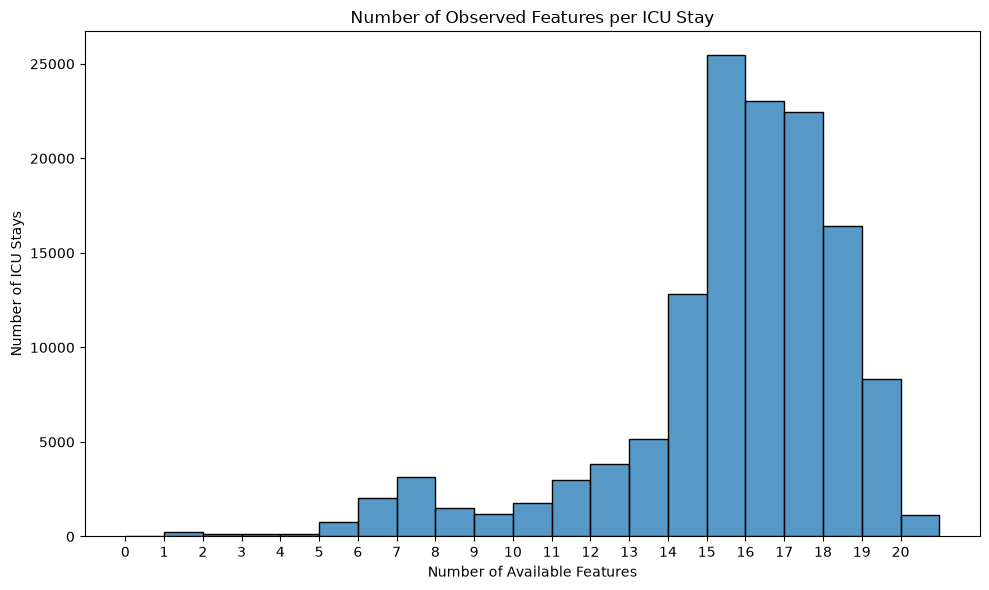

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=analytic_before_imputation,
    x="observed_feature_count",
    bins=range(0, len(FEATURES) + 2),
)

plt.title(
    "Number of Observed Features per ICU Stay"
)
plt.xlabel(
    "Number of Available Features"
)
plt.ylabel(
    "Number of ICU Stays"
)

plt.xticks(
    range(0, len(FEATURES) + 1)
)

plt.tight_layout()

plt.savefig(
    MISSINGNESS_PLOTS_DIR
    / "observed_features_per_stay.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Explanation :
This plot shows the overall completeness of the ICU-stay records.

It helps determine whether the selected minimum of 10 observed variables is reasonable.

### Remove ICU Stays with Very Limited Information

In [28]:
analytic_before_imputation = apply_exclusion(
    analytic_before_imputation,
    (
        analytic_before_imputation[
            "observed_feature_count"
        ]
        >= MINIMUM_OBSERVED_FEATURES
    ),
    (
        f"At least {MINIMUM_OBSERVED_FEATURES} "
        f"of the {len(FEATURES)} features are observed"
    ),
)


analytic_before_imputation = (
    analytic_before_imputation
    .drop(
        columns="observed_feature_count"
    )
    .reset_index(drop=True)
)


print(
    "ICU stays after the completeness requirement:",
    len(analytic_before_imputation),
)

ICU stays after the completeness requirement: 123400


#### Explanation :
ICU stays with fewer than $10$ observed variables are excluded.

Imputing most of a patient's record would create a row that mainly represents population median values rather than the patient's actual condition.

The threshold can be changed through:
```
MINIMUM_OBSERVED_FEATURES
```

### Save the Cohort Exclusion Table

In [29]:
cohort_exclusion_summary = pd.DataFrame(
    cohort_flow_rows
)


cohort_exclusion_summary.to_csv(
    RESULTS_DIR / "cohort_exclusion_summary.csv",
    index=False,
)


cohort_exclusion_summary

,criterion,before_exclusion,excluded,after_exclusion
0,All ICU stay records in the patient table,200859,0,200859
1,Valid ICU stay identifier,200859,0,200859
2,Remove duplicate ICU stay identifiers,200859,0,200859
3,Known patient age,200859,95,200764
4,Adult ICU stays with age 18 years or older,200764,530,200234
5,ICU stay lasting at least 24 hours,200234,67623,132611
6,At least 10 of the 20 features are observed,132611,9211,123400


#### Explanation :
This is the required table showing the number of ICU stays :
- Before each exclusion
- Removed by each exclusion
- Remaining after each exclusion

It is saved as :
```
results/analytic_dataset/cohort_exclusion_summary.csv
```

### Summarize the Implausible Values

In [30]:
implausible_values_summary = pd.DataFrame(
    {
        "variable": FEATURES,
        "values_changed_to_missing": [
            implausible_value_counts.get(
                feature,
                0,
            )
            for feature in FEATURES
        ],
    }
)


implausible_values_summary = (
    implausible_values_summary
    .sort_values(
        "values_changed_to_missing",
        ascending=False,
    )
    .reset_index(drop=True)
)


implausible_values_summary.to_csv(
    RESULTS_DIR / "implausible_values_summary.csv",
    index=False,
)


implausible_values_summary

,variable,values_changed_to_missing
0,respiratory_rate,306551
1,temperature,62095
2,mean_arterial_pressure,50953
3,oxygen_saturation,14486
4,heart_rate,4829
5,bicarbonate,554
6,wbc,89
7,glucose,44
8,urine_output,43
9,creatinine,21


#### Explanation :
This table reports how many source values were outside the selected broad limits and were changed to missing values.

A very large number for one variable may indicate:
- Incorrect units
- An incorrect source column
- An overly narrow limit
- A data-quality problem

### Calculate Descriptive Statistics

In [31]:
descriptive_statistics = (
    analytic_before_imputation[FEATURES]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .transpose()
)

descriptive_statistics[
    "iqr"
] = (
    descriptive_statistics["75%"]
    - descriptive_statistics["25%"]
)


descriptive_statistics.to_csv(
    RESULTS_DIR
    / "descriptive_statistics_before_imputation.csv"
)


descriptive_statistics

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr
age,123400.0,63.839084,16.517556,18.0,21.0,31.0,54.0,66.0,76.0,88.0,90.0,90.0,22.0
heart_rate,121734.0,85.456485,16.412827,24.0,52.82631,60.820692,73.523898,84.249126,96.236888,114.175831,126.96126,172.666667,22.71299
mean_arterial_pressure,121746.0,80.845024,13.479961,20.0,55.666667,61.860116,71.085837,79.212121,89.071429,105.535714,117.747704,163.0,17.985591
respiratory_rate,113095.0,19.742991,4.768653,4.0,11.664303,13.515756,16.413378,18.975524,22.260246,28.498223,34.285333,80.0,5.846867
oxygen_saturation,120722.0,96.860097,2.188818,55.0,90.95162,93.267373,95.572917,97.088287,98.492895,99.768113,99.991889,100.0,2.919978
temperature,13557.0,36.955343,1.121815,25.395,32.844187,34.894649,36.631754,37.120628,37.568008,38.213117,38.958389,43.85,0.936254
gcs,93946.0,12.109307,3.808694,3.0,3.0,3.0,10.0,14.0,15.0,15.0,15.0,15.0,5.0
urine_output,92526.0,1694.216383,1347.718501,0.0,0.0,120.0,775.0,1400.0,2275.0,4200.0,6293.75,19850.0,1500.0
wbc,116128.0,12.309371,7.668944,0.1,2.0,4.5,7.8,10.8,14.9,24.7,37.6,198.1,7.1
hemoglobin,116828.0,10.952198,2.312789,2.1,6.1,7.3,9.2,10.9,12.6,14.8,16.373,23.6,3.4


#### Explanation :
The descriptive-statistics table contains:

- Available count
- Mean
- Standard deviation
- Minimum
- Percentiles
- Median
- Maximum
- Interquartile range

The statistics are calculated before imputation so that the original data availability remains visible.

### Calculate the Missingness Summary

In [32]:
missingness_summary = pd.DataFrame(
    {
        "variable": FEATURES,

        "available_count": [
            analytic_before_imputation[
                feature
            ].notna().sum()
            for feature in FEATURES
        ],

        "missing_count": [
            analytic_before_imputation[
                feature
            ].isna().sum()
            for feature in FEATURES
        ],
    }
)


missingness_summary[
    "missing_percent"
] = (
    missingness_summary[
        "missing_count"
    ]
    / len(analytic_before_imputation)
    * 100
)


missingness_summary = (
    missingness_summary
    .sort_values(
        "missing_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)


missingness_summary.to_csv(
    RESULTS_DIR
    / "missingness_summary_before_imputation.csv",
    index=False,
)


missingness_summary

,variable,available_count,missing_count,missing_percent
0,temperature,13557,109843,89.013776
1,lactate,34969,88431,71.662075
2,inr,49251,74149,60.088331
3,total_bilirubin,54834,68566,55.564019
4,albumin,60631,62769,50.866288
5,urine_output,92526,30874,25.019449
6,gcs,93946,29454,23.868720
7,respiratory_rate,113095,10305,8.350891
8,platelets,115073,8327,6.747974
9,wbc,116128,7272,5.893031


#### Explanation :
This is the required missingness summary.
It shows :
- Number of available values
- Number of missing values
- Percentage missing for every feature

### Display Missingness Warnings

In [33]:
high_missingness_variables = (
    missingness_summary[
        missingness_summary[
            "missing_percent"
        ]
        >= MISSINGNESS_WARNING_PERCENT
    ]
)


if high_missingness_variables.empty:
    print(
        "No variable has missingness at or above "
        f"{MISSINGNESS_WARNING_PERCENT}%."
    )

else:
    print(
        "Warning: the following variables have high missingness:"
    )

    display(high_missingness_variables)

,variable,available_count,missing_count,missing_percent
0,temperature,13557,109843,89.013776
1,lactate,34969,88431,71.662075
2,inr,49251,74149,60.088331
3,total_bilirubin,54834,68566,55.564019
4,albumin,60631,62769,50.866288


#### Explanation :
This cell identifies variables for which at least 50% of ICU stays are missing.

Median imputation may not be sufficient for heavily missing variables. Variables such as lactate, bilirubin, albumin, and INR may require additional consideration depending on the resulting missingness.

The notebook keeps all 20 variables because they are your finalized feature set, but it reports the problem clearly.

### Plot the Missingness Percentages

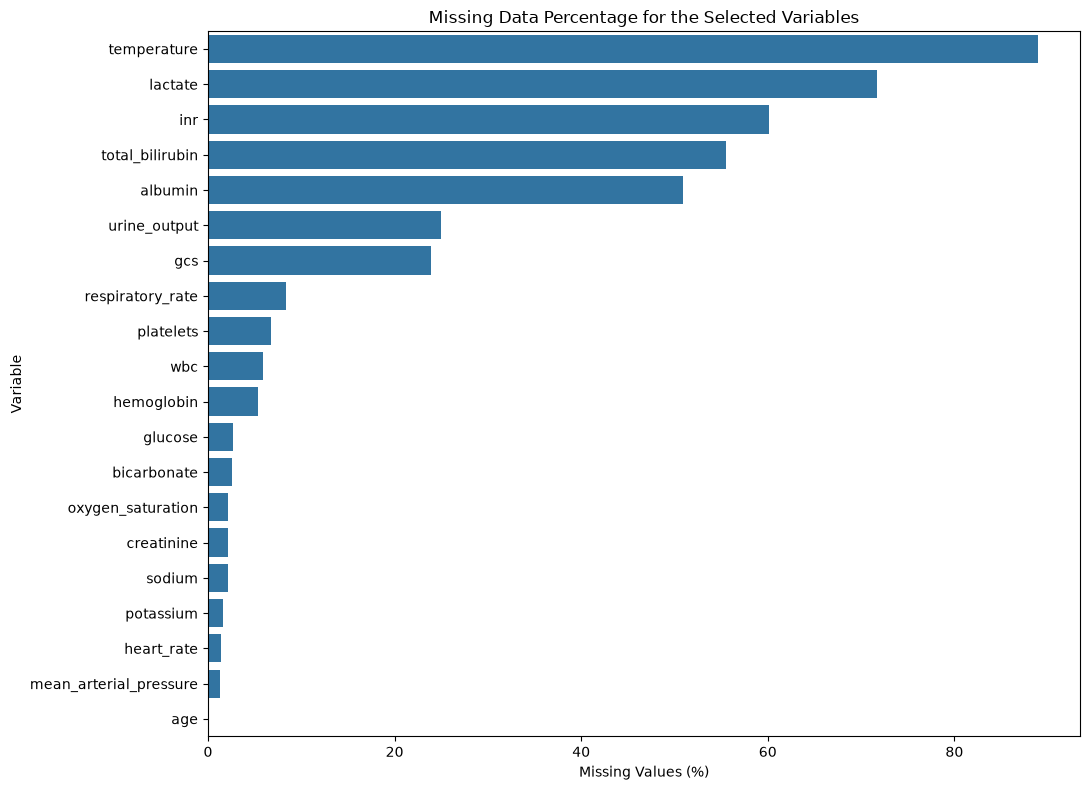

In [34]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=missingness_summary,
    x="missing_percent",
    y="variable",
)

plt.title(
    "Missing Data Percentage for the Selected Variables"
)
plt.xlabel(
    "Missing Values (%)"
)
plt.ylabel(
    "Variable"
)

plt.tight_layout()

plt.savefig(
    MISSINGNESS_PLOTS_DIR
    / "missingness_percentage.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Explanation :
The horizontal bar chart makes it easy to compare missingness across the $20$ variables.

Longer bars indicate variables with more missing data.

### Create an Individual Histogram for Every Variable

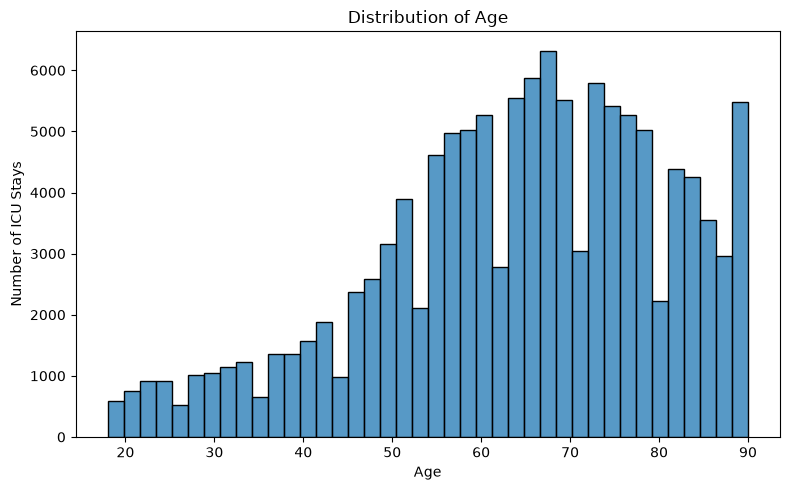

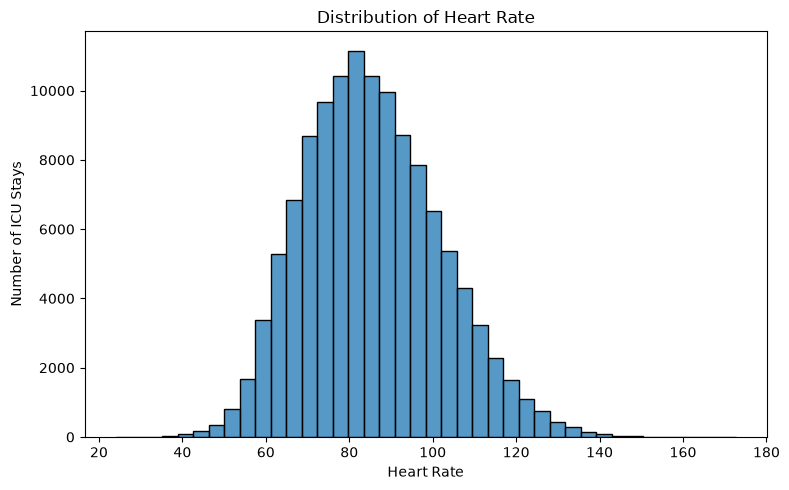

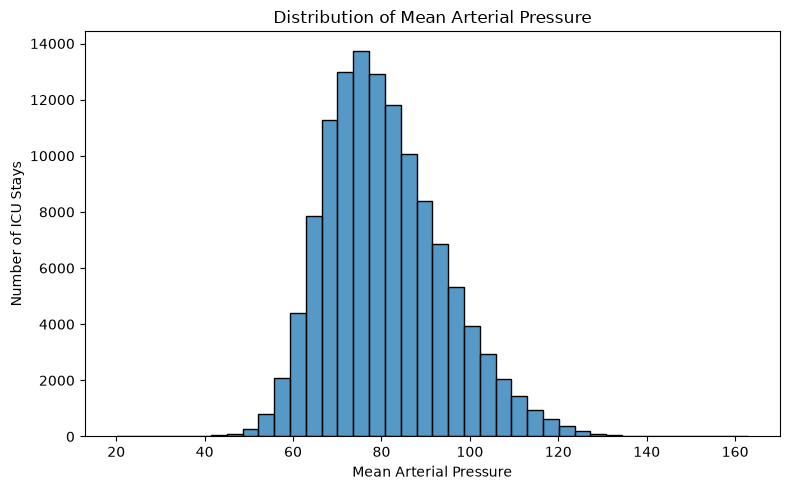

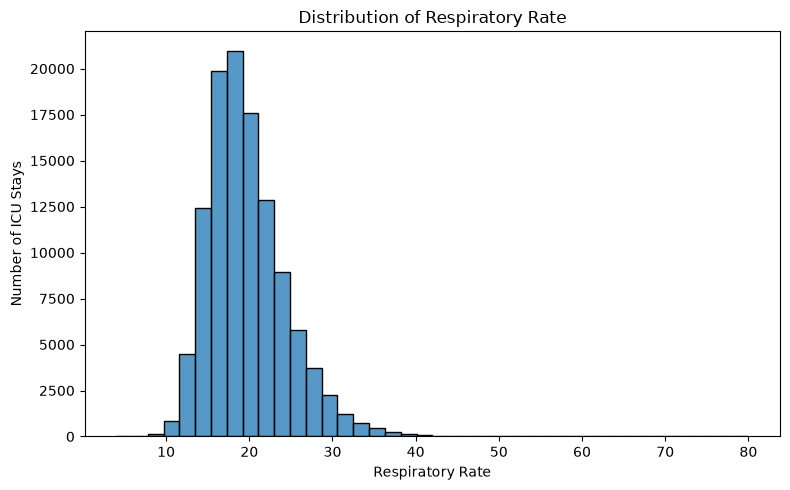

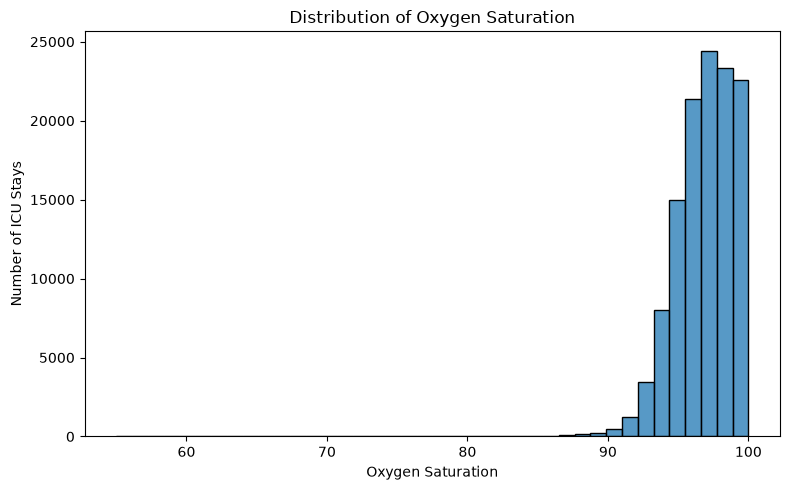

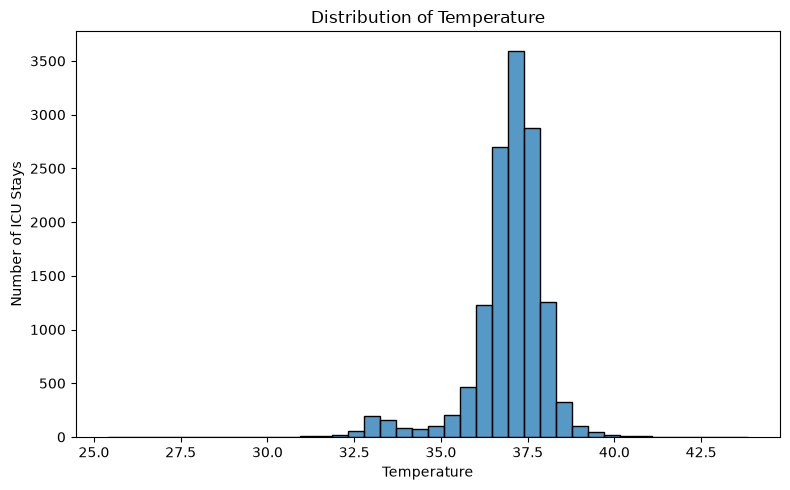

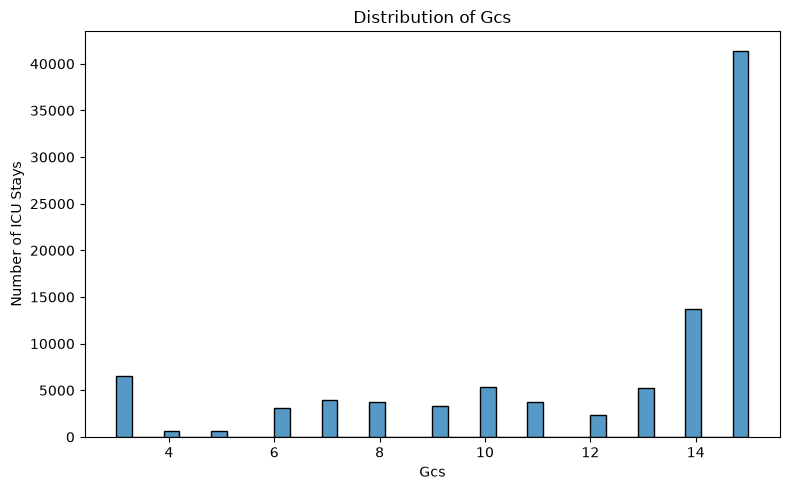

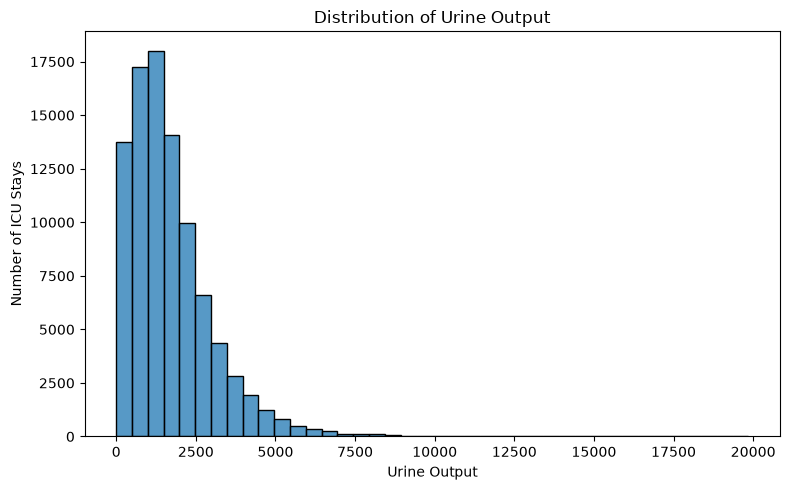

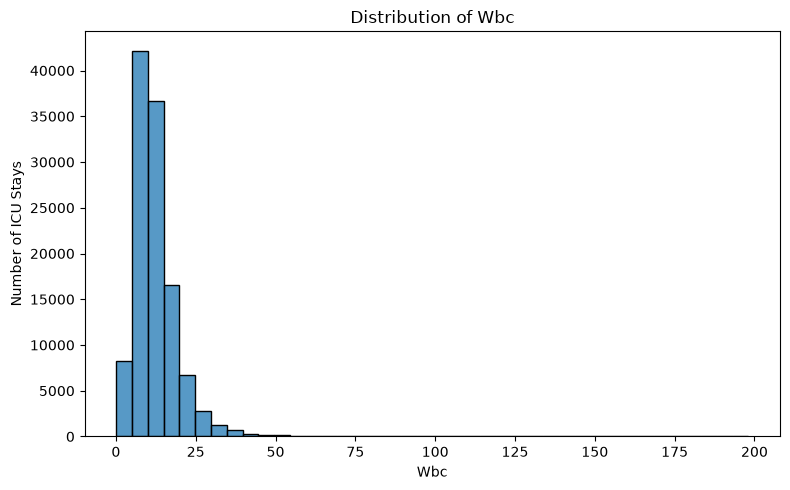

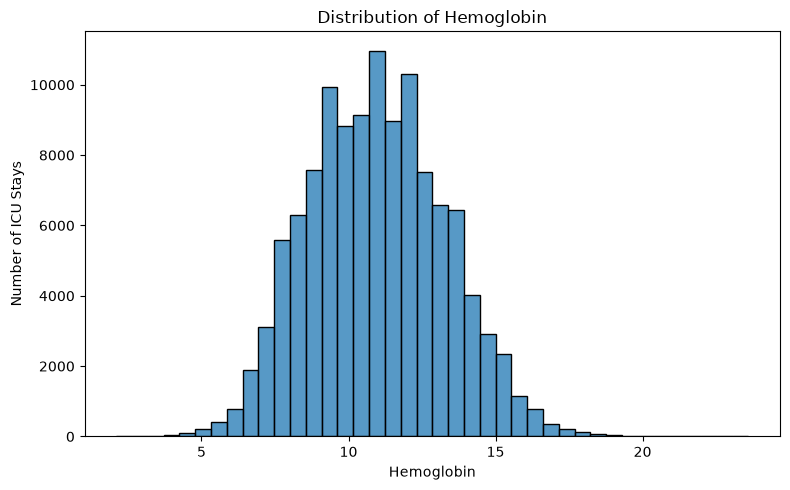

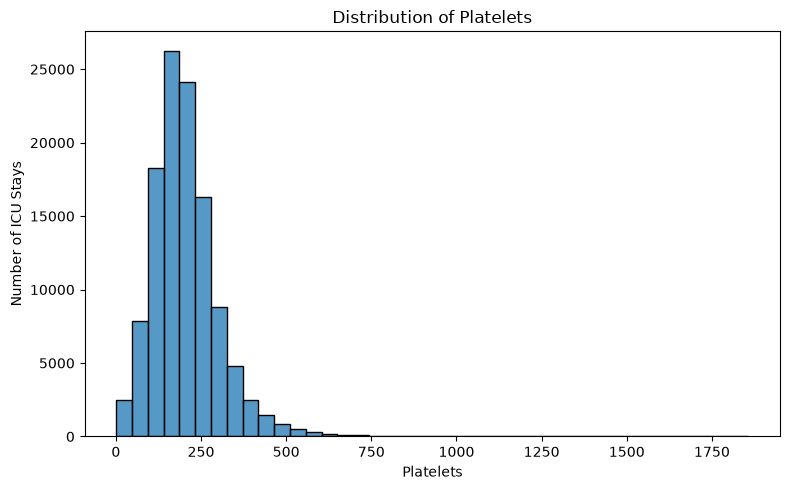

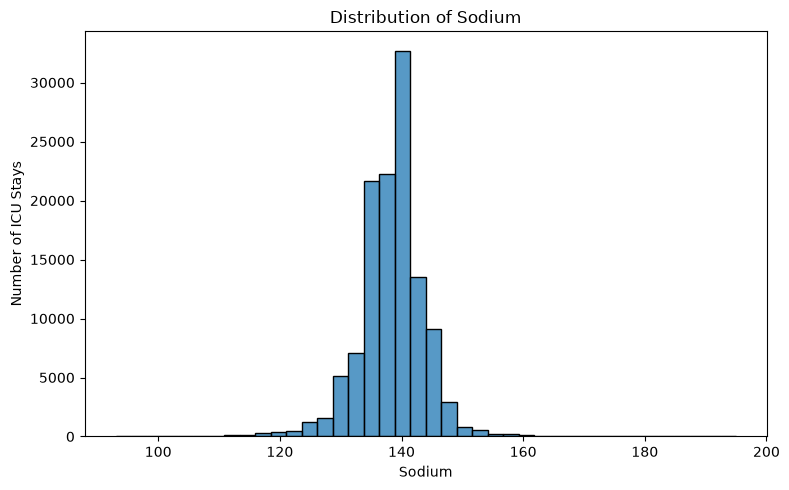

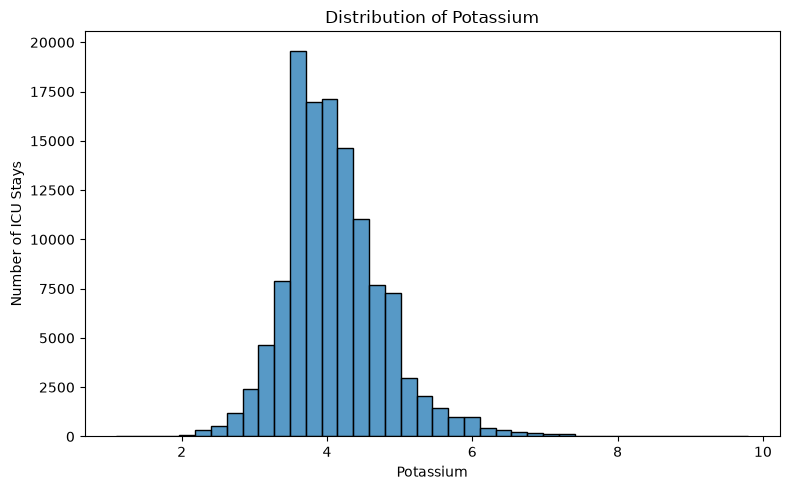

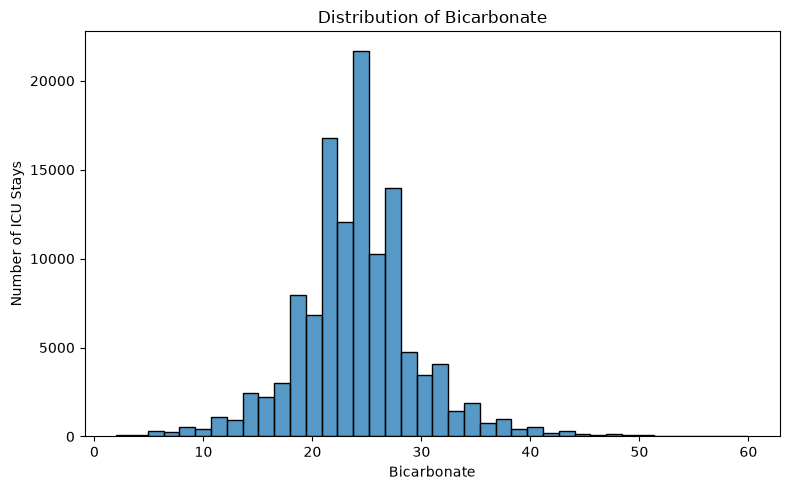

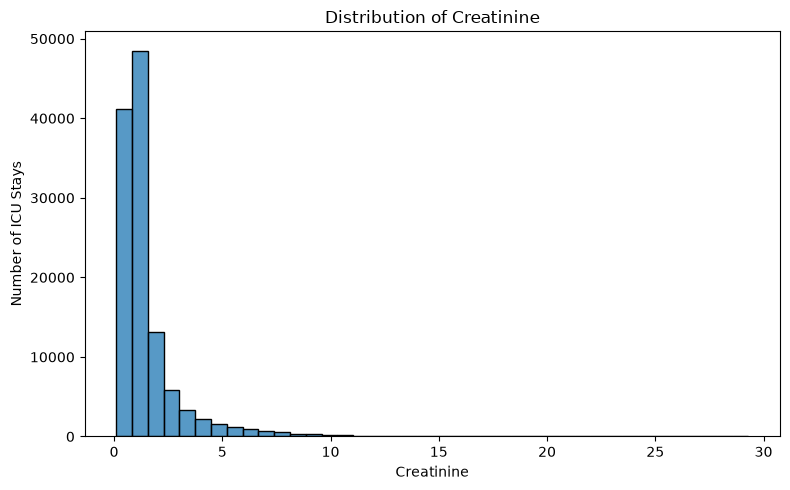

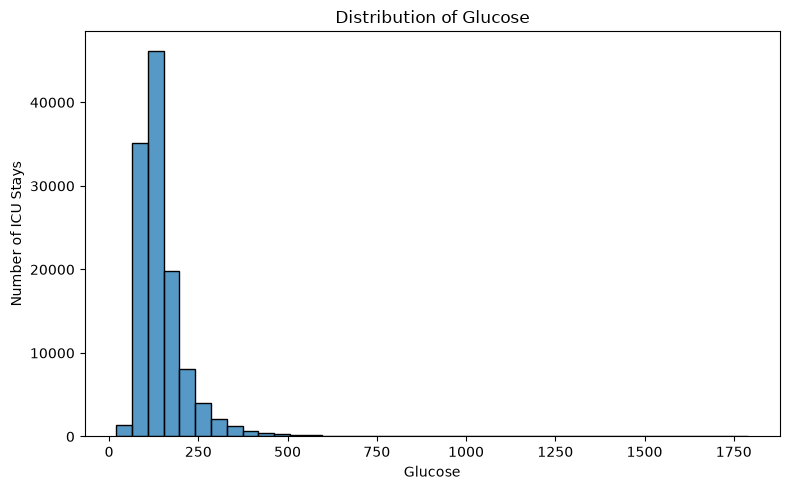

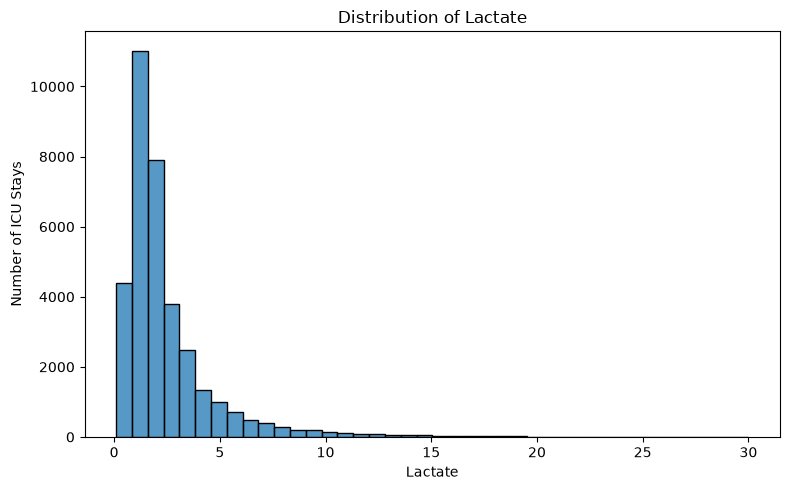

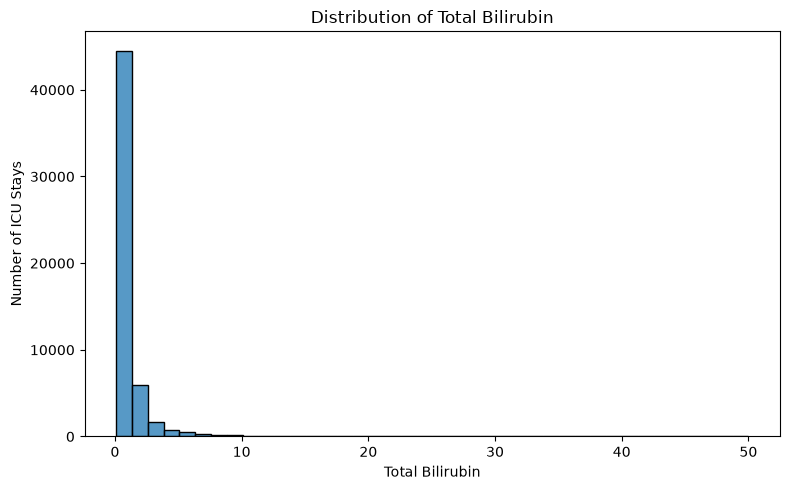

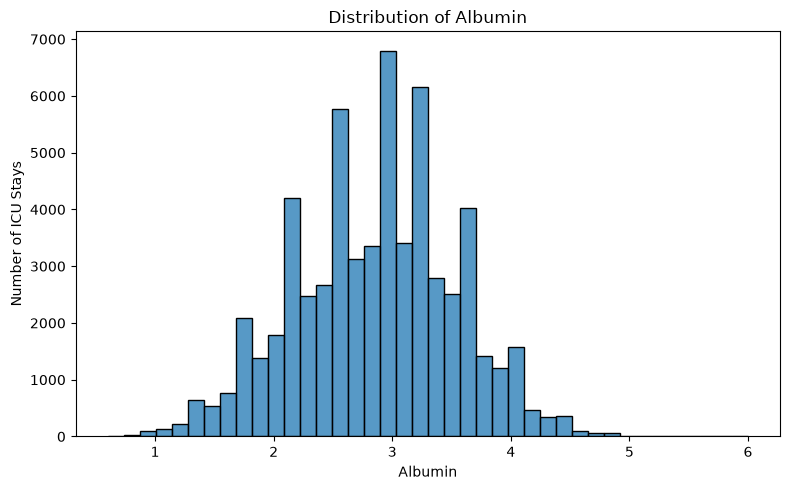

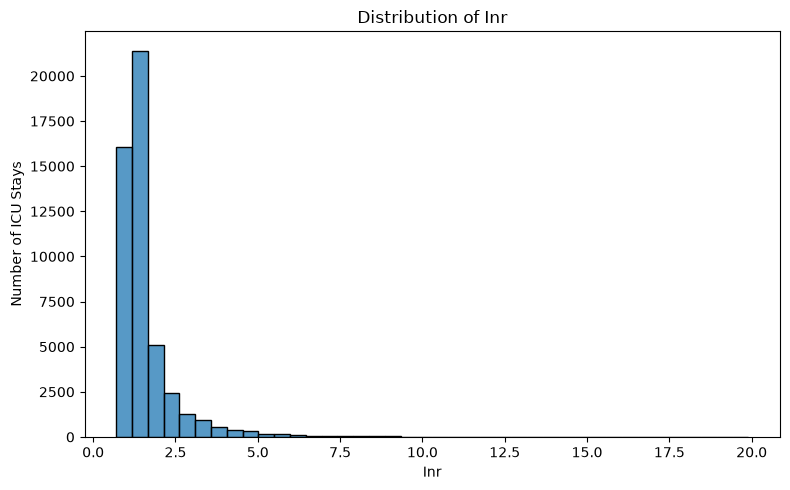

In [35]:
for feature in FEATURES:

    feature_values = (
        analytic_before_imputation[
            feature
        ]
        .dropna()
    )


    plt.figure(figsize=(8, 5))

    sns.histplot(
        feature_values,
        bins=40,
    )

    plt.title(
        f"Distribution of {feature.replace('_', ' ').title()}"
    )

    plt.xlabel(
        feature.replace("_", " ").title()
    )

    plt.ylabel(
        "Number of ICU Stays"
    )

    plt.tight_layout()


    plot_path = (
        DISTRIBUTION_PLOTS_DIR
        / f"{feature}_histogram.png"
    )


    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close()

#### Explanation :
This creates and saves one histogram for each variable.

The plots help identify:

- Skewed distributions
- Unusual peaks
- Possible unit problems
- Extreme values
- Variables with limited variation

The plots are saved inside:
```
plots/analytic_dataset/distributions/
```

### Create a Combined Distribution Figure

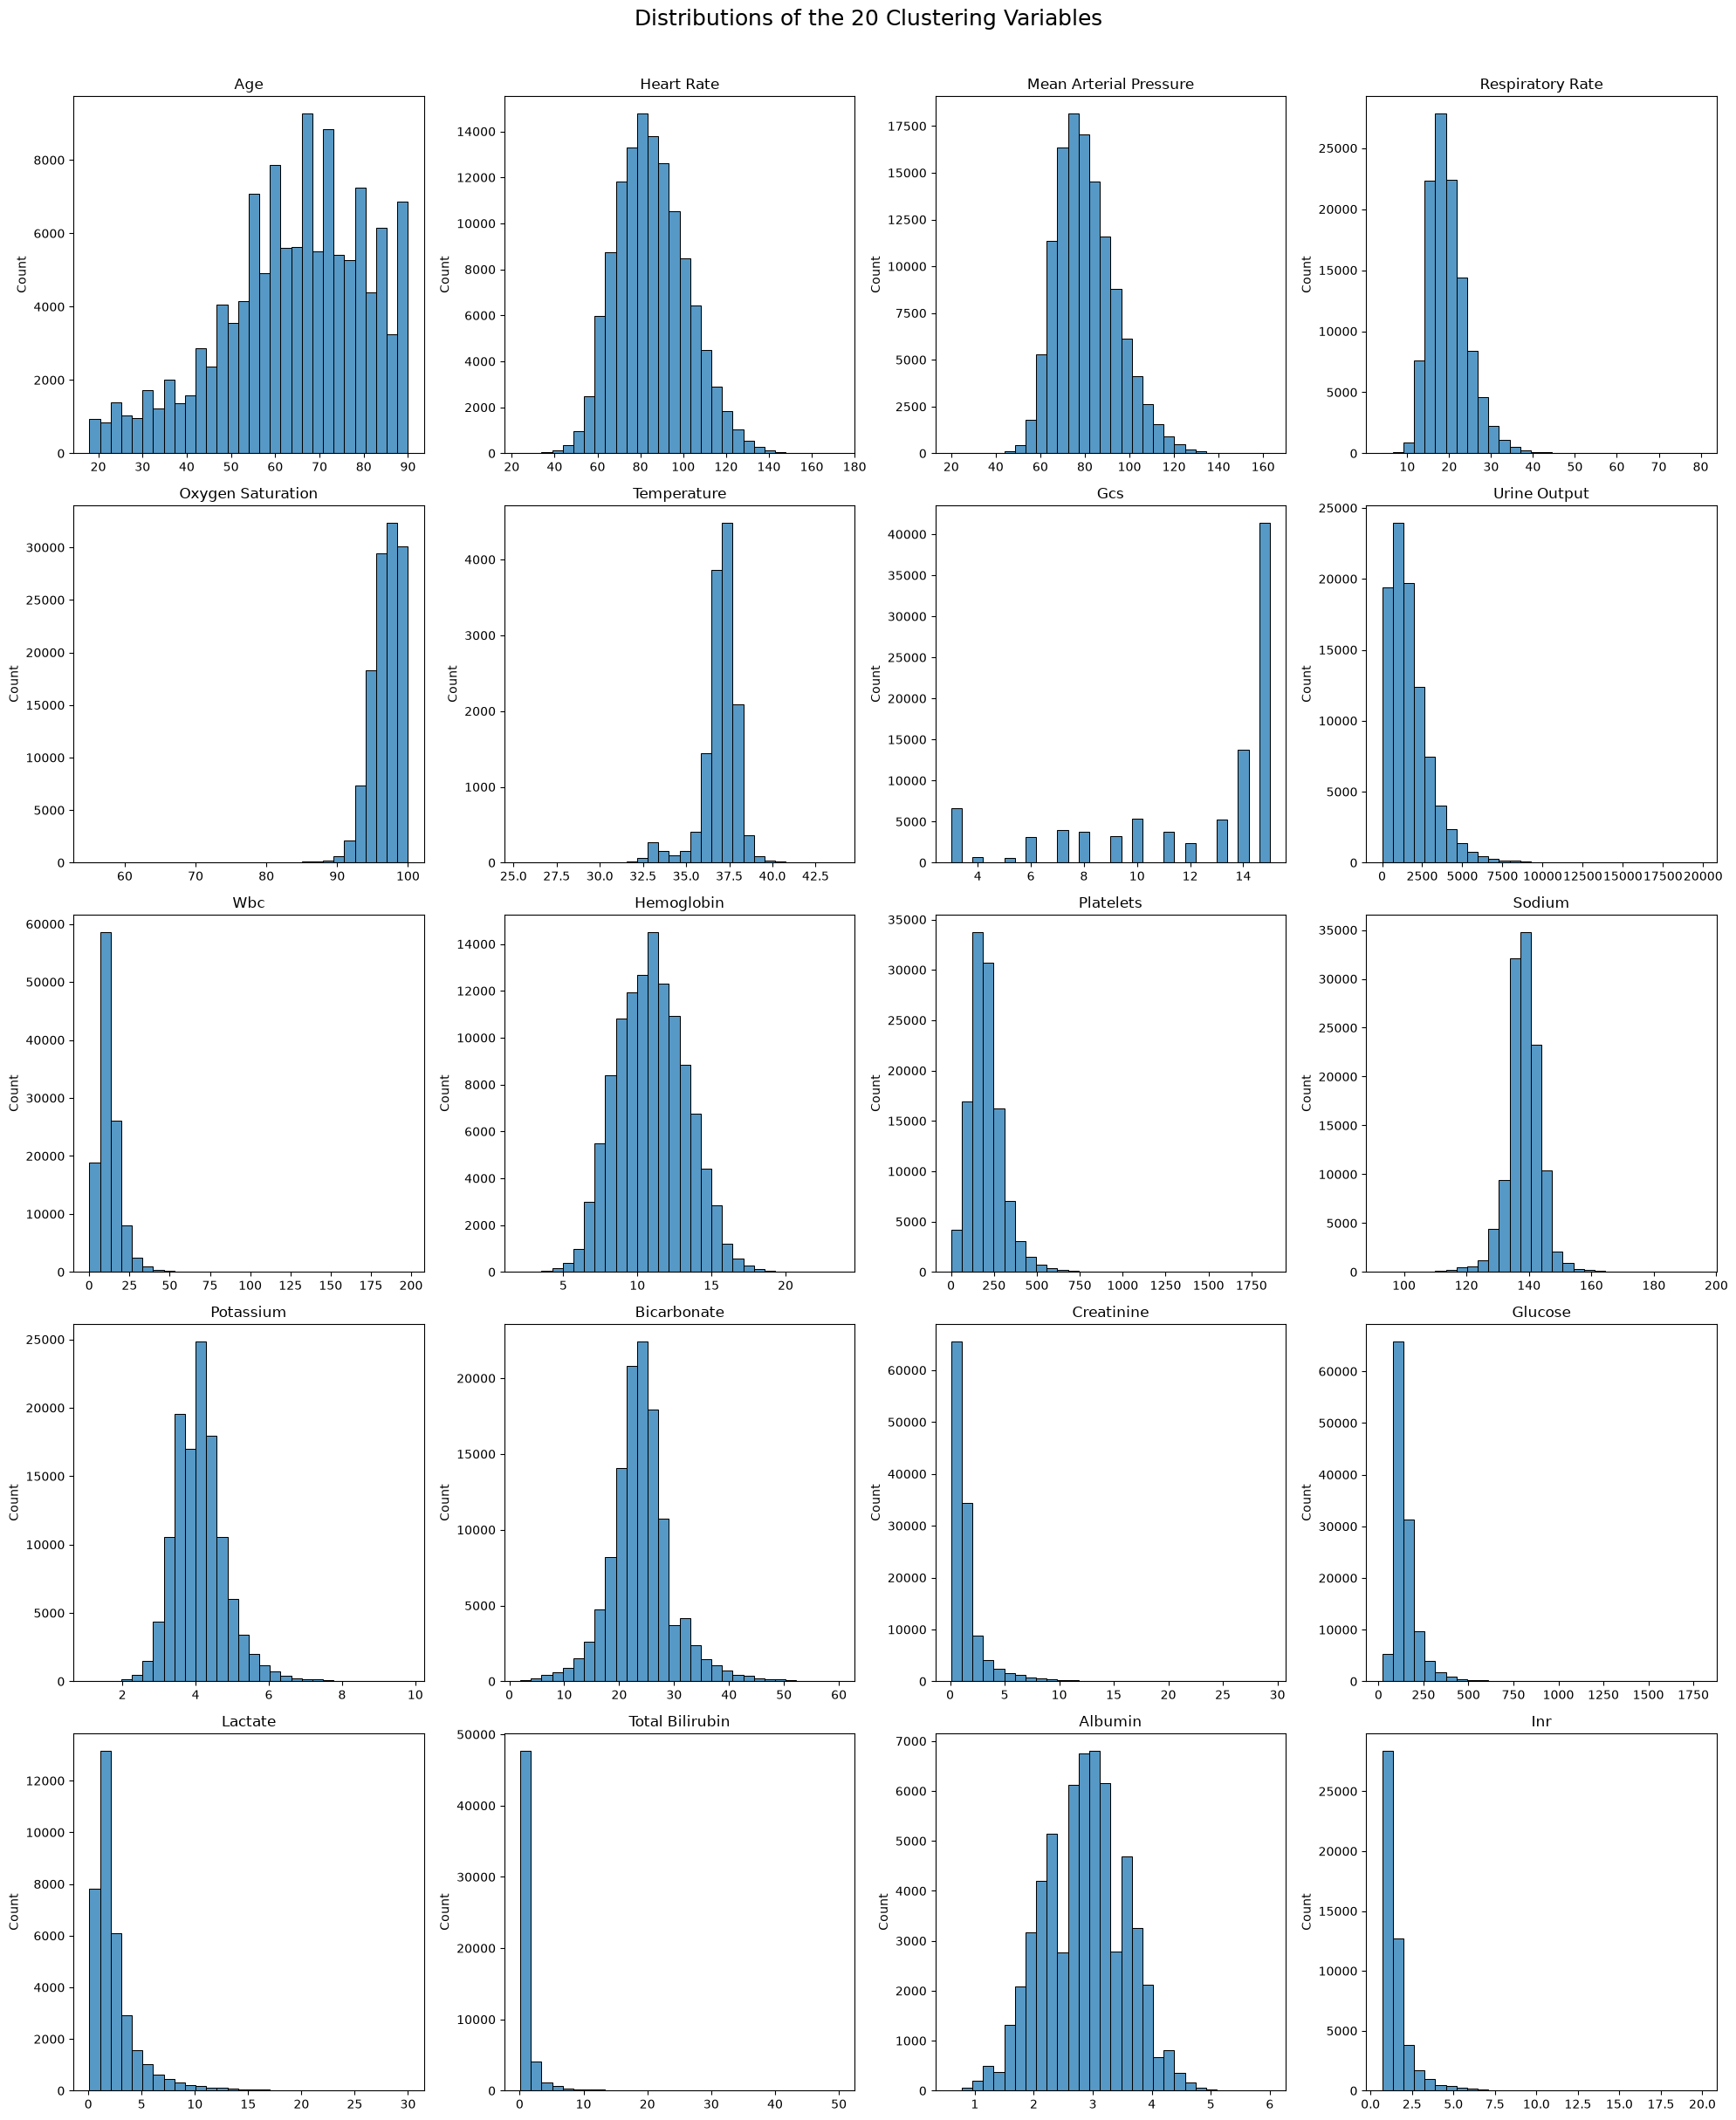

In [36]:
figure, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 24),
)


axes = axes.flatten()


for axis, feature in zip(
    axes,
    FEATURES,
):

    feature_values = (
        analytic_before_imputation[
            feature
        ]
        .dropna()
    )


    sns.histplot(
        feature_values,
        bins=30,
        ax=axis,
    )


    axis.set_title(
        feature.replace("_", " ").title()
    )

    axis.set_xlabel("")
    axis.set_ylabel("Count")


plt.suptitle(
    "Distributions of the 20 Clustering Variables",
    fontsize=18,
    y=1.01,
)

plt.tight_layout()


plt.savefig(
    DISTRIBUTION_PLOTS_DIR
    / "all_variable_distributions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Explanation :
This places all 20 histograms in one figure.

It is useful for obtaining a quick overview of the complete analytic feature set.

### Check for Completely Missing Variables

In [37]:
completely_missing_features = [
    feature
    for feature in FEATURES
    if analytic_before_imputation[
        feature
    ].isna().all()
]


if completely_missing_features:
    raise ValueError(
        "The following variables are completely missing: "
        f"{completely_missing_features}. "
        "Review the source columns and laboratory aliases "
        "before continuing."
    )

else:
    print(
        "All 20 variables contain at least one observed value."
    )

All 20 variables contain at least one observed value.


#### Explanation :

A median cannot be calculated for a completely missing variable.

If this error appears, the source mapping for that feature must be corrected before continuing.

### Apply the Initial Missing-Data Strategy

In [38]:
# Use median imputation for all 20 numerical variables
median_imputer = SimpleImputer(
    strategy="median"
)


imputed_feature_values = (
    median_imputer.fit_transform(
        analytic_before_imputation[
            FEATURES
        ]
    )
)


imputed_features = pd.DataFrame(
    imputed_feature_values,
    columns=FEATURES,
    index=analytic_before_imputation.index,
)


# Reattach the ICU stay identifier
analytic_dataset = pd.concat(
    [
        analytic_before_imputation[
            [ID_COLUMN]
        ].reset_index(drop=True),

        imputed_features.reset_index(
            drop=True
        ),
    ],
    axis=1,
)


print(
    "Missing values after imputation:",
    analytic_dataset[FEATURES]
    .isna()
    .sum()
    .sum(),
)


analytic_dataset.head()

Missing values after imputation: 0


,patientunitstayid,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141168,70.0,125.052830,66.200000,18.975524,86.741935,37.120628,14.0,1400.0,9.8,...,209.0,139.0,4.0,26.0,1.95,131.0,1.7,2.60,3.1,1.7
1,141179,52.0,92.295139,82.466667,18.975524,98.747253,37.120628,9.0,1900.0,10.8,...,191.0,146.0,3.6,22.0,0.70,54.0,1.7,0.62,2.9,1.3
2,141194,68.0,86.860627,61.224138,23.193662,98.589474,37.120628,15.0,1855.0,14.1,...,233.0,135.0,4.0,19.0,2.51,165.0,1.3,0.40,2.3,1.3
3,141196,71.0,82.305147,94.571429,24.114815,95.509434,37.120628,15.0,650.0,26.2,...,453.0,135.0,4.1,30.0,0.80,144.0,1.7,0.30,2.5,1.3
4,141203,77.0,91.538194,75.343511,18.713208,98.102473,37.120628,14.0,1400.0,12.7,...,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.50,1.6,1.3


#### Explanation :
Median imputation replaces a missing value with the median observed value of that variable.

Median imputation is used as the initial strategy because it is less affected by very high or low values than mean imputation.

This is an initial approach. More advanced sensitivity analyses can later compare:

- Median imputation
- K-nearest-neighbor imputation
- Iterative imputation
- Complete-case analysis
- Missingness indicators

### Save the Inputation Values

In [39]:
imputation_summary = pd.DataFrame(
    {
        "variable": FEATURES,
        "median_imputation_value": (
            median_imputer.statistics_
        ),
    }
)


imputation_summary.to_csv(
    RESULTS_DIR / "median_imputation_values.csv",
    index=False,
)


imputation_summary

,variable,median_imputation_value
0,age,66.000000
1,heart_rate,84.249126
2,mean_arterial_pressure,79.212121
3,respiratory_rate,18.975524
4,oxygen_saturation,97.088287
5,temperature,37.120628
6,gcs,14.000000
7,urine_output,1400.000000
8,wbc,10.800000
9,hemoglobin,10.900000


#### Explanation :
This file records the exact median value used to fill missing data for each variable.

It makes the missing-data process transparent and reproducible.

### Save the Main Analytic Dataset

In [40]:
analytic_dataset.to_csv(
    ANALYTIC_DATASET_PATH,
    index=False,
)


print(
    f"Analytic dataset saved to:\n"
    f"{ANALYTIC_DATASET_PATH}"
)


print(
    "\nAnalytic dataset shape:",
    analytic_dataset.shape,
)

Analytic dataset saved to:
C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv

Analytic dataset shape: (123400, 21)


#### Explanation :
The main analytic dataset is saved as:
```
data/analytic_dataset.csv
```
It contains:

- One ICU stay identifier
- Twenty clustering variables
- Cleaned values
- Implausible values handled
- Missing values imputed
- Variables in their original understandable measurement scales

It contains $21$ columns in total.

### Calculate the Correlation Matrix

In [41]:
correlation_matrix = (
    analytic_dataset[FEATURES]
    .corr(method="pearson")
)


correlation_matrix.to_csv(
    RESULTS_DIR / "correlation_matrix.csv"
)


correlation_matrix

,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
age,1.000000,-0.178254,-0.129960,0.056801,-0.085942,-0.015660,0.031113,-0.182309,-0.002402,-0.121852,-0.065388,0.040380,0.054432,0.110403,0.019278,-0.031983,-0.009467,-0.062867,-0.070061,0.063625
heart_rate,-0.178254,1.000000,-0.014408,0.276751,-0.083158,0.097248,-0.073091,0.013099,0.156505,-0.074187,0.068199,-0.011016,-0.002926,-0.135767,0.010486,0.099533,0.134320,0.063864,-0.144161,0.051871
mean_arterial_pressure,-0.129960,-0.014408,1.000000,0.062023,-0.010545,-0.002691,0.082586,0.090336,-0.098393,0.239591,0.072956,0.012198,-0.068867,0.099977,-0.035979,0.013698,-0.087811,-0.073492,0.196144,-0.098277
respiratory_rate,0.056801,0.276751,0.062023,1.000000,-0.185182,0.037753,0.022155,-0.018199,0.092621,-0.019467,0.045455,-0.007332,-0.008126,-0.026094,0.010278,0.037736,0.096759,0.032100,-0.069665,0.061641
oxygen_saturation,-0.085942,-0.083158,-0.010545,-0.185182,1.000000,-0.019552,-0.155116,0.006064,-0.005256,-0.138054,-0.008589,0.045881,-0.041874,-0.131336,0.024311,0.023429,-0.036886,-0.005366,-0.012485,-0.044836
temperature,-0.015660,0.097248,-0.002691,0.037753,-0.019552,1.000000,0.071677,0.014515,-0.023312,-0.004281,0.010242,-0.002759,-0.015036,0.030218,-0.030845,-0.047308,-0.085182,-0.014592,0.013631,-0.025085
gcs,0.031113,-0.073091,0.082586,0.022155,-0.155116,0.071677,1.000000,0.025288,-0.104250,0.005008,0.037758,-0.141252,0.004481,0.082259,-0.015879,-0.064797,-0.176735,-0.040358,0.055519,-0.026444
urine_output,-0.182309,0.013099,0.090336,-0.018199,0.006064,0.014515,0.025288,1.000000,-0.034715,0.058540,0.016515,-0.015341,-0.075743,0.027360,-0.122875,0.011897,-0.058859,-0.046635,0.078601,-0.046137
wbc,-0.002402,0.156505,-0.098393,0.092621,-0.005256,-0.023312,-0.104250,-0.034715,1.000000,0.021836,0.233173,-0.010869,0.077277,-0.139832,0.031167,0.114885,0.116220,0.025274,-0.096998,0.041678
hemoglobin,-0.121852,-0.074187,0.239591,-0.019467,-0.138054,-0.004281,0.005008,0.058540,0.021836,1.000000,0.019585,-0.014805,-0.031343,0.051637,-0.177480,0.050372,-0.009721,-0.071402,0.296382,-0.090623


#### Explanation :
The correlation matrix measures the linear relationship between every pair of variables.

Values near :
- `+1` indicate a strong positive relationship
- `-1` indicate a strong negative relationship
- `0` indicate little linear relationship


### Create the Correlation Heatmap

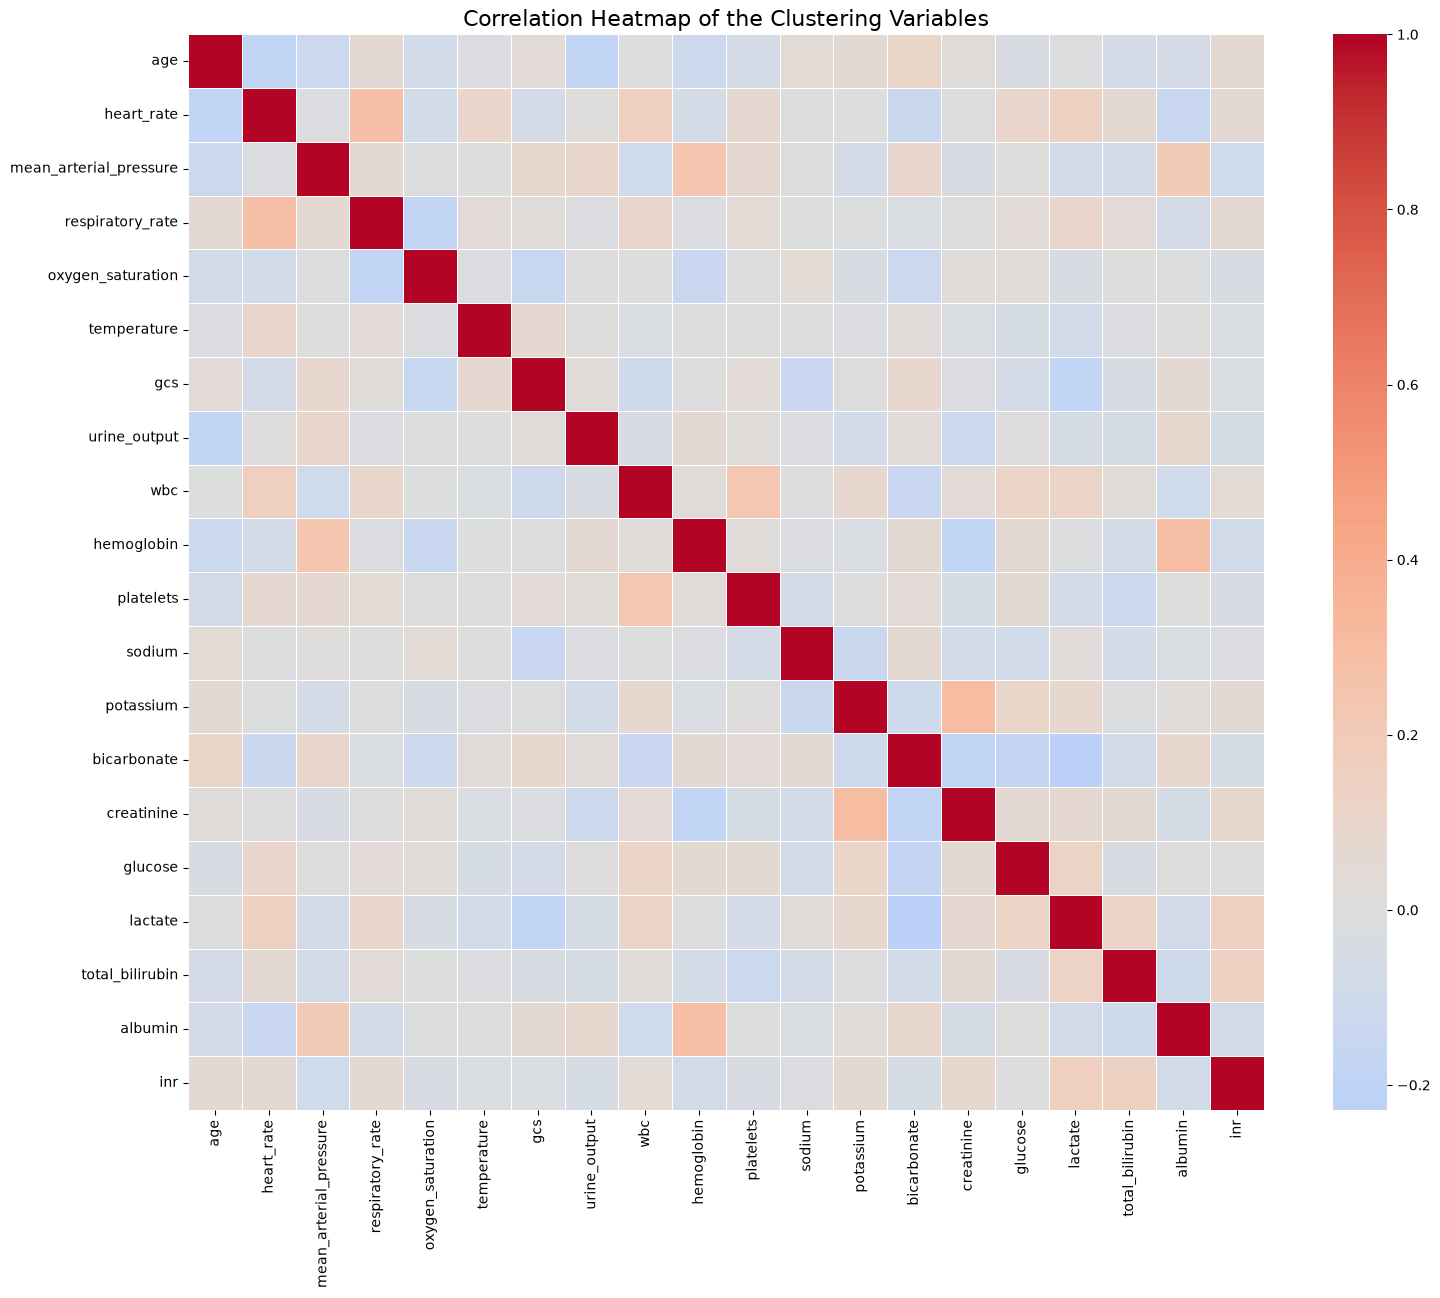

In [42]:
plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title(
    "Correlation Heatmap of the Clustering Variables",
    fontsize=16,
)

plt.tight_layout()


plt.savefig(
    CORRELATION_PLOTS_DIR
    / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Explanation :
The heatmap provides a visual summary of feature relationships.
It can help identify:
- Strongly related variables
- Possible redundant features
- Unexpected relationships
- Groups of features representing similar physiological systems.

### Identify Strong Correlations

In [43]:
# Keep only the upper half of the matrix so each pair
# appears only once
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape,
            dtype=bool,
        ),
        k=1,
    )
)


strong_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)


strong_correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlation",
]


strong_correlation_pairs[
    "absolute_correlation"
] = (
    strong_correlation_pairs[
        "correlation"
    ].abs()
)


strong_correlation_pairs = (
    strong_correlation_pairs[
        strong_correlation_pairs[
            "absolute_correlation"
        ]
        >= 0.80
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)


strong_correlation_pairs.to_csv(
    RESULTS_DIR / "strong_correlation_pairs.csv",
    index=False,
)


strong_correlation_pairs

,variable_1,variable_2,correlation,absolute_correlation


#### Explanation :

This table reports feature pairs with an absolute correlation of at least `0.80`.

Strongly correlated features are not automatically removed. Their clinical meaning and effect on clustering should first be evaluated.

### Calculate Feature Skewness

In [44]:
skewness_before_transformation = (
    analytic_dataset[FEATURES]
    .skew()
)


skewness_table = pd.DataFrame(
    {
        "variable": FEATURES,
        "skewness_before": [
            skewness_before_transformation[
                feature
            ]
            for feature in FEATURES
        ],
    }
)


skewness_table[
    "absolute_skewness"
] = (
    skewness_table[
        "skewness_before"
    ].abs()
)


skewness_table[
    "highly_skewed"
] = (
    skewness_table[
        "absolute_skewness"
    ]
    >= SKEWNESS_THRESHOLD
)


skewness_table = (
    skewness_table
    .sort_values(
        "absolute_skewness",
        ascending=False,
    )
    .reset_index(drop=True)
)


skewness_table

,variable,skewness_before,absolute_skewness,highly_skewed
0,total_bilirubin,12.174066,12.174066,True
1,inr,8.088864,8.088864,True
2,temperature,-7.508460,7.508460,True
3,lactate,6.831537,6.831537,True
4,wbc,4.855399,4.855399,True
5,glucose,4.750647,4.750647,True
6,creatinine,4.421209,4.421209,True
7,urine_output,2.422861,2.422861,True
8,oxygen_saturation,-1.777259,1.777259,True
9,platelets,1.652271,1.652271,True


#### Explanation :

Skewness measures whether a distribution has a long tail.

The notebook considers a variable highly skewed when:
```
absolute skewness ≥ 1
```
Highly skewed features can cause a small number of extreme values to influence Euclidean distances strongly.

### Apply Suitable Transformations

In [45]:
# These variables can reasonably receive a log1p transformation
# because they are non-negative and may have long right tails.

LOG_TRANSFORM_CANDIDATES = [
    "urine_output",
    "wbc",
    "platelets",
    "creatinine",
    "glucose",
    "lactate",
    "total_bilirubin",
    "inr",
]


# Begin with the imputed original-scale features
clustering_features = (
    analytic_dataset[FEATURES]
    .copy()
)


transformation_records = []
transformed_features = []


for feature in FEATURES:

    skew_before = (
        skewness_before_transformation[
            feature
        ]
    )

    is_highly_skewed = (
        abs(skew_before)
        >= SKEWNESS_THRESHOLD
    )

    transformation = "None"


    if (
        is_highly_skewed
        and feature in LOG_TRANSFORM_CANDIDATES
        and clustering_features[
            feature
        ].min() >= 0
    ):

        clustering_features[
            feature
        ] = np.log1p(
            clustering_features[
                feature
            ]
        )

        transformation = "log1p"

        transformed_features.append(feature)


    elif is_highly_skewed:
        transformation = (
            "None - review manually"
        )


    skew_after = (
        clustering_features[
            feature
        ].skew()
    )


    transformation_records.append(
        {
            "variable": feature,
            "skewness_before": skew_before,
            "highly_skewed": is_highly_skewed,
            "transformation": transformation,
            "skewness_after": skew_after,
        }
    )


transformation_summary = pd.DataFrame(
    transformation_records
)


transformation_summary.to_csv(
    RESULTS_DIR / "transformation_summary.csv",
    index=False,
)


transformation_summary

,variable,skewness_before,highly_skewed,transformation,skewness_after
0,age,-0.568868,False,None,-0.568868
1,heart_rate,0.358864,False,None,0.358864
2,mean_arterial_pressure,0.611421,False,None,0.611421
3,respiratory_rate,1.290284,True,None - review manually,1.290284
4,oxygen_saturation,-1.777259,True,None - review manually,-1.777259
5,temperature,-7.508460,True,None - review manually,-7.508460
6,gcs,-1.593620,True,None - review manually,-1.593620
7,urine_output,2.422861,True,log1p,-3.425114
8,wbc,4.855399,True,log1p,-0.240752
9,hemoglobin,0.167117,False,None,0.167117


#### Explanation :
The `log1p` transformation calculates:
```
np.log1p(x)
```
which means :
```
log(1+x)
```
It can be used when a non-negative variable has a long right tail.

The transformation is applied only when:

- The feature has absolute skewness of at least 1
- It belongs to the approved transformation list
- It contains no negative values

The original values in `analytic_dataset.csv` are not replaced. Transformations are applied only to the copy used to create the clustering matrix.

### Compare Distributions Before and After Transformation

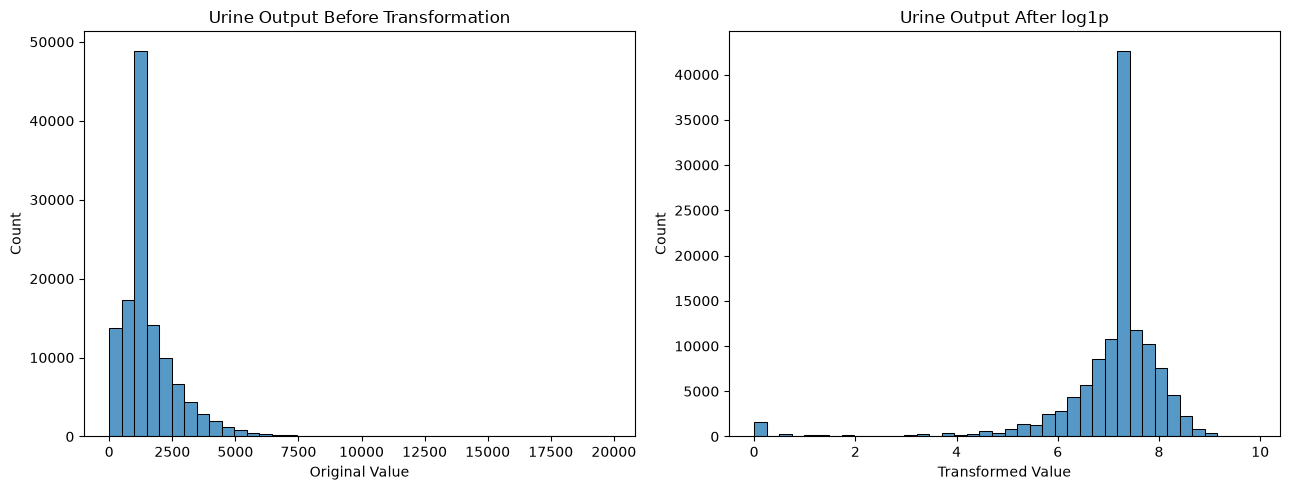

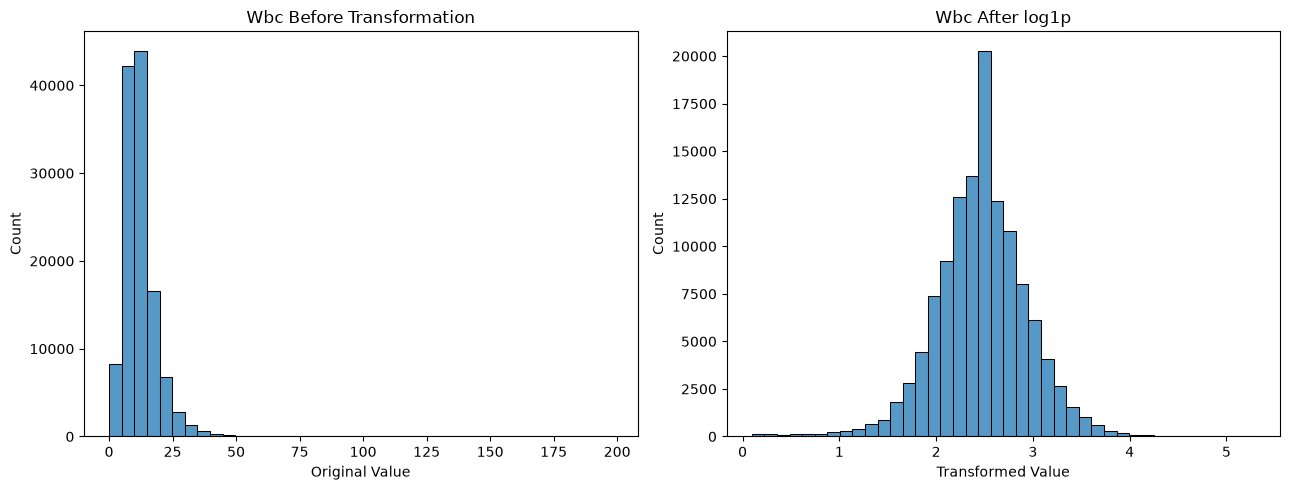

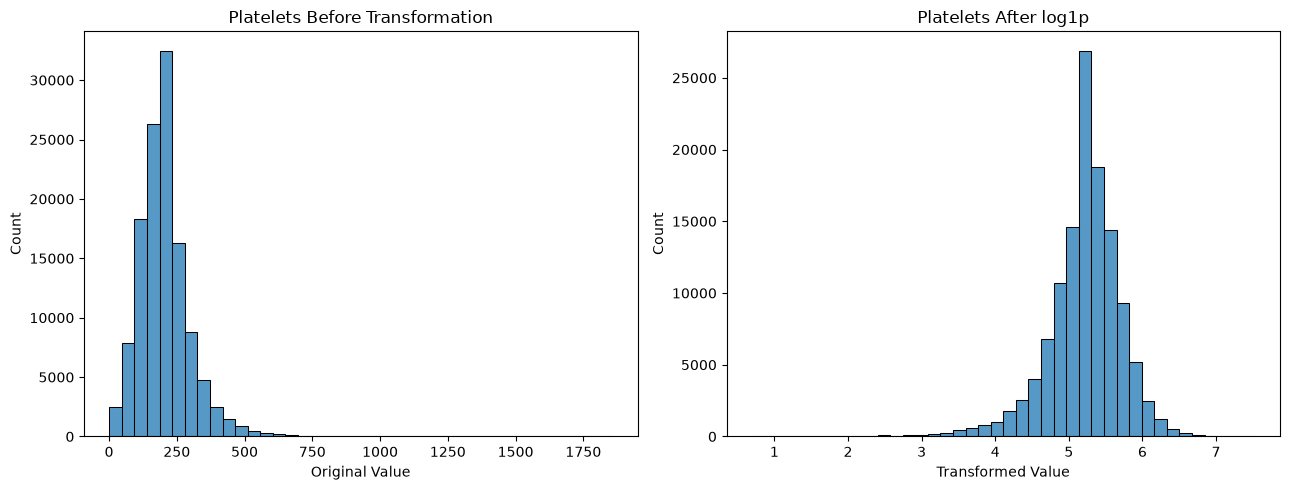

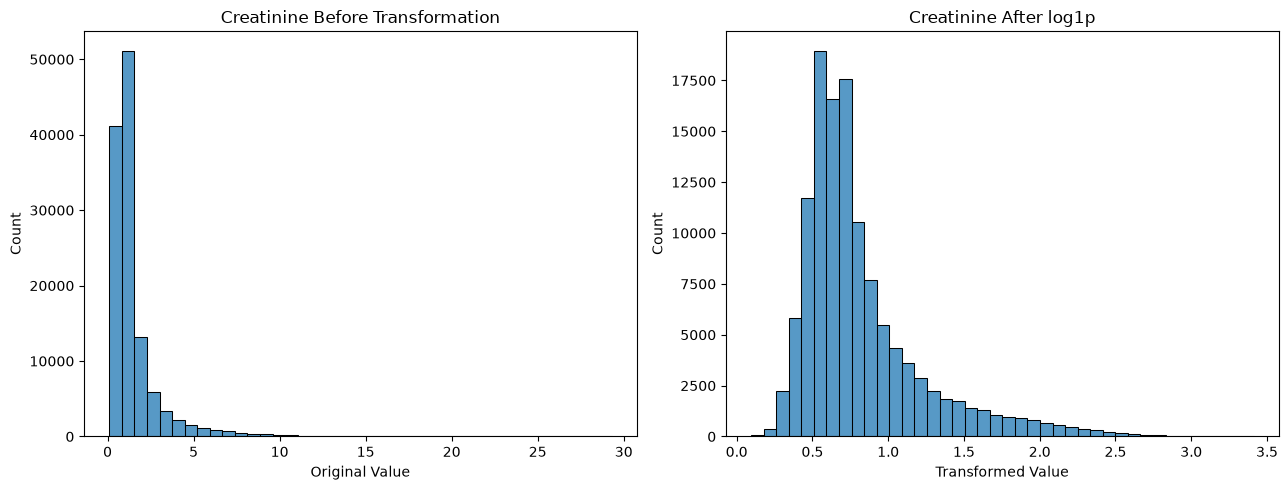

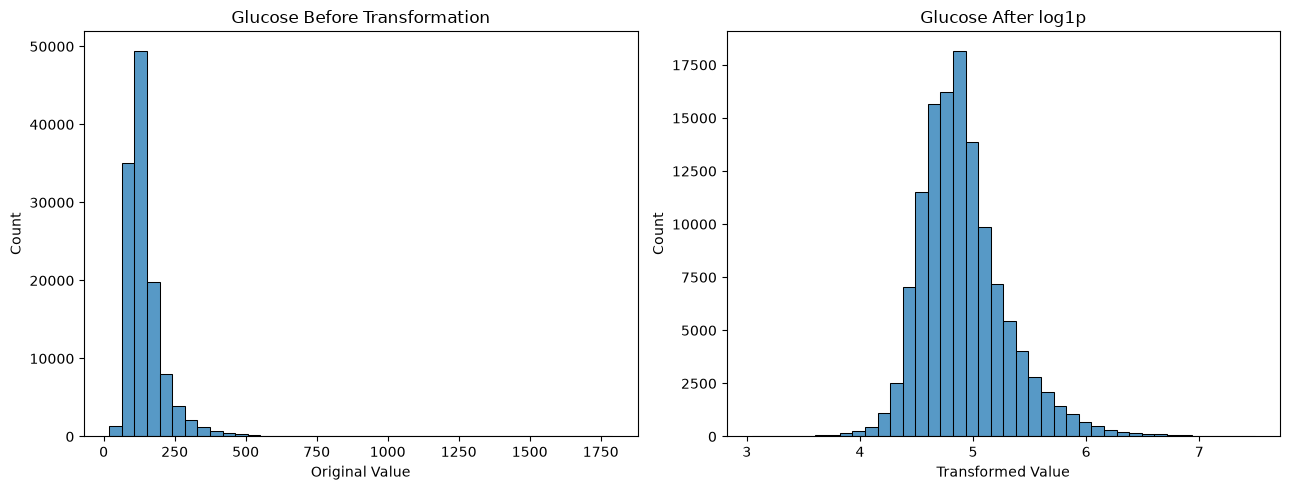

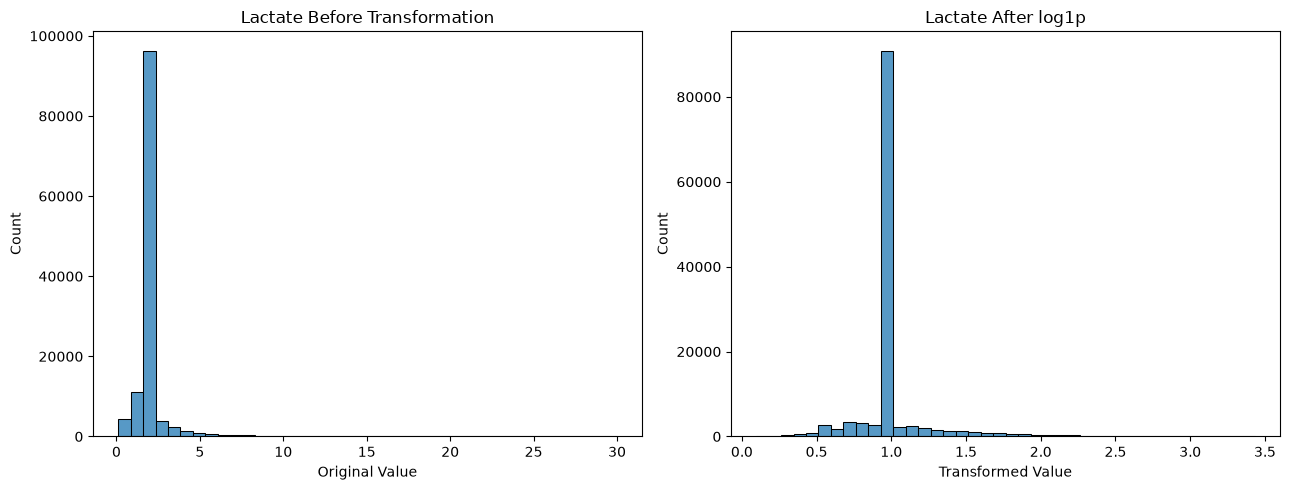

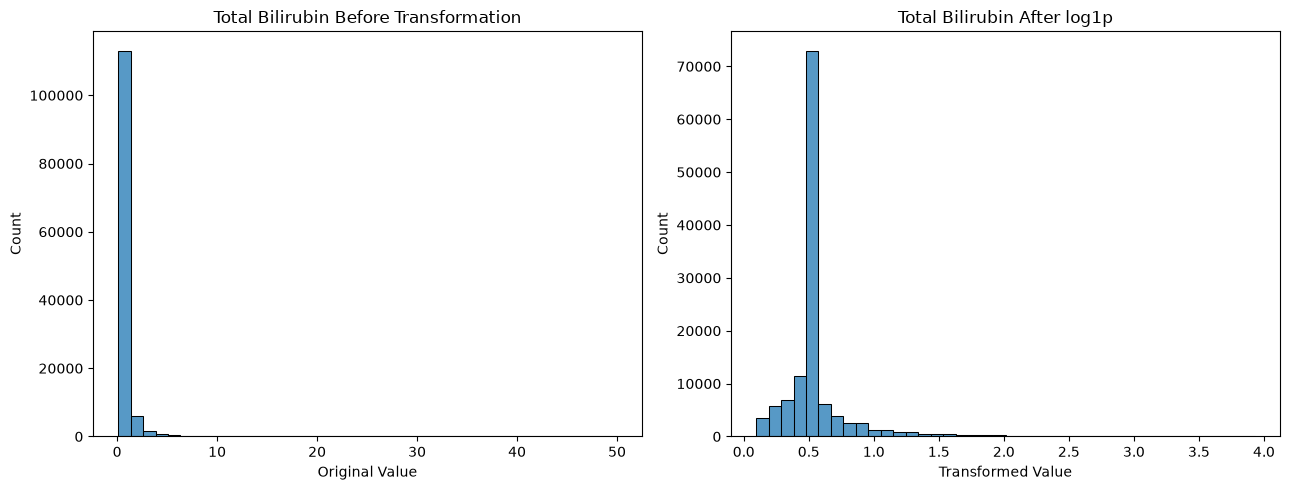

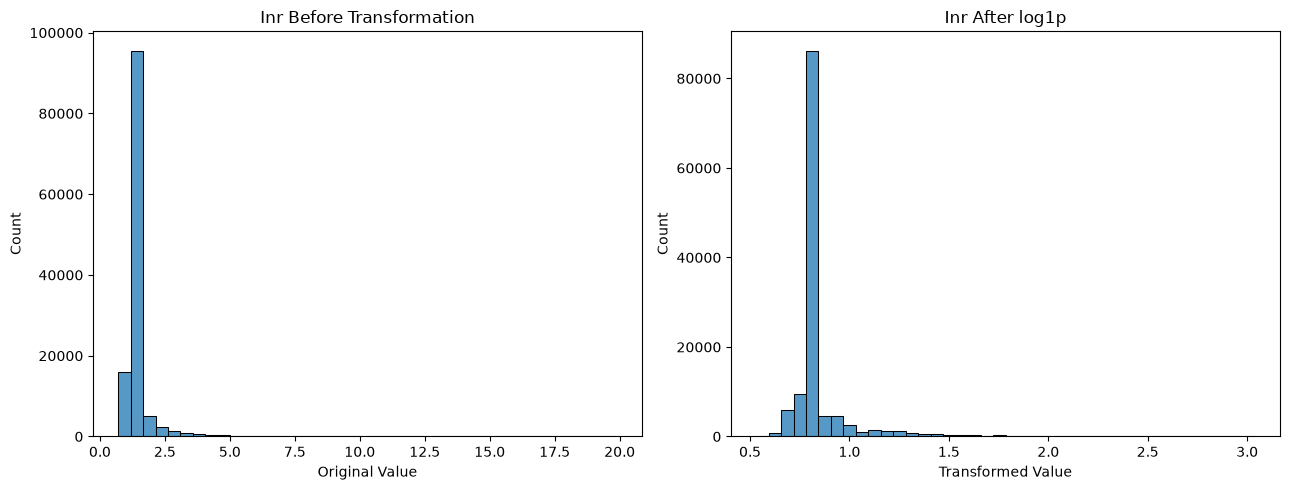

In [46]:
for feature in transformed_features:

    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(13, 5),
    )


    sns.histplot(
        analytic_dataset[feature],
        bins=40,
        ax=axes[0],
    )

    axes[0].set_title(
        f"{feature.replace('_', ' ').title()} Before Transformation"
    )

    axes[0].set_xlabel(
        "Original Value"
    )


    sns.histplot(
        clustering_features[feature],
        bins=40,
        ax=axes[1],
    )

    axes[1].set_title(
        f"{feature.replace('_', ' ').title()} After log1p"
    )

    axes[1].set_xlabel(
        "Transformed Value"
    )


    plt.tight_layout()


    plt.savefig(
        TRANSFORMATION_PLOTS_DIR
        / f"{feature}_transformation.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :

These plots show whether the transformation reduced the long right tail of each selected skewed variable.

They are saved inside :
```
plots/analytic_dataset/transformations/
```

### Standardize the Clustering Variables

In [47]:
standard_scaler = StandardScaler()


standardized_values = (
    standard_scaler.fit_transform(
        clustering_features
    )
)


clustering_matrix_standardized = pd.DataFrame(
    standardized_values,
    columns=FEATURES,
    index=analytic_dataset.index,
)


clustering_matrix_standardized.head()

,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,0.372993,2.429898,-1.092047,-0.153908,-4.675407,0.048372,0.420938,0.171026,-0.180633,0.911215,0.272638,0.126787,-0.147079,0.338843,0.636506,-0.077523,-0.117033,2.303692,0.459271,0.757233
1,-0.716761,0.420493,0.122738,-0.153908,0.869305,0.048372,-1.041252,0.421561,0.003892,-0.021960,0.096108,1.444785,-0.731267,-0.377193,-0.704919,-2.327021,-0.117033,-0.208007,0.041380,-0.181118
2,0.251910,0.087132,-1.463641,0.769075,0.796434,0.048372,0.713375,0.401895,0.517741,-0.910698,0.485813,-0.626355,-0.147079,-0.914220,1.059517,0.511365,-0.723111,-0.667104,-1.212293,-0.181118
3,0.433535,-0.192308,1.026714,0.970635,-0.626097,0.048372,0.713375,-0.458141,1.744088,-0.288582,1.791442,-0.626355,-0.001032,1.054880,-0.565810,0.163833,-0.117033,-0.900210,-0.794402,-0.181118
4,0.796787,0.374061,-0.409215,-0.211306,0.571510,0.048372,0.420938,0.171026,0.314992,0.155788,2.197765,1.256499,0.145016,0.159834,-0.914081,0.181493,1.813832,-0.450087,-2.674911,-0.181118


#### Explanation :

K-Means uses Euclidean distance. A variable with a large numerical range can dominate a variable with a small range.

`StandardScaler` changes every feature so that it has approximately:

- Mean of $0$
- Population standard deviation of $1$

The ICU stay identifier is not standardized and is not included in the clustering matrix.

### Check the Standardized Features

In [48]:
standardization_check = pd.DataFrame(
    {
        "variable": FEATURES,

        "standardized_mean": [
            clustering_matrix_standardized[
                feature
            ].mean()
            for feature in FEATURES
        ],

        "standardized_standard_deviation": [
            clustering_matrix_standardized[
                feature
            ].std(ddof=0)
            for feature in FEATURES
        ],
    }
)


standardization_check.to_csv(
    RESULTS_DIR / "standardization_check.csv",
    index=False,
)


standardization_check

,variable,standardized_mean,standardized_standard_deviation
0,age,1.474059e-17,1.0
1,heart_rate,6.301604e-16,1.0
2,mean_arterial_pressure,-5.509297e-16,1.0
3,respiratory_rate,-7.794090e-16,1.0
4,oxygen_saturation,6.430584e-16,1.0
5,temperature,6.653075e-15,1.0
6,gcs,2.137386e-16,1.0
7,urine_output,4.127367e-16,1.0
8,wbc,6.605629e-16,1.0
9,hemoglobin,-7.766451e-16,1.0


#### Explanation :

A correctly standardized feature should have:
```
Mean ≈ 0
Standard deviation ≈ 1 
```

Very small differences from exactly zero are normal because of floating-point calculations.

### Save the Scaler Parameters

In [49]:
scaler_parameters = pd.DataFrame(
    {
        "variable": FEATURES,
        "scaler_mean": standard_scaler.mean_,
        "scaler_scale": standard_scaler.scale_,
    }
)


scaler_parameters.to_csv(
    RESULTS_DIR / "standard_scaler_parameters.csv",
    index=False,
)


scaler_parameters

,variable,scaler_mean,scaler_scale
0,age,63.839084,16.517489
1,heart_rate,85.440185,16.302186
2,mean_arterial_pressure,80.823138,13.390578
3,respiratory_rate,19.678901,4.570115
4,oxygen_saturation,96.865049,2.165183
5,temperature,37.102469,0.375393
6,gcs,12.560592,3.419530
7,urine_output,7.036603,1.218169
8,wbc,2.466232,0.479899
9,hemoglobin,10.949418,2.250381


#### Explanation :

This table records the mean and scale used by `StandardScaler`.

It can be used to understand or reproduce the standardization process.

The scaler means apply to the transformed clustering features, not necessarily the original clinical-scale variables.

### Save the Standardized Clustering Matrix

In [50]:
clustering_matrix_standardized.to_csv(
    CLUSTERING_MATRIX_PATH,
    index=False,
)


print(
    f"Standardized clustering matrix saved to:\n"
    f"{CLUSTERING_MATRIX_PATH}"
)


print(
    "\nStandardized matrix shape:",
    clustering_matrix_standardized.shape,
)

Standardized clustering matrix saved to:
C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv

Standardized matrix shape: (123400, 20)


#### Explanation :
The K-Means-ready matrix is saved as:
```
data/clustering_matrix_standardized.csv
```
It contains:
- The 20 clustering variables
- No ICU stay identifier
- No missing values
- Selected transformations
- Standardized values

This is the file that can be loaded directly for future K-Means analysis.

### Save the ICU-Stay Identifiers in Matching Row Order

In [51]:
clustering_row_ids = analytic_dataset[
    [ID_COLUMN]
].copy()


clustering_row_ids[
    "clustering_row_number"
] = np.arange(
    len(clustering_row_ids)
)


clustering_row_ids = clustering_row_ids[
    [
        "clustering_row_number",
        ID_COLUMN,
    ]
]


clustering_row_ids.to_csv(
    RESULTS_DIR / "clustering_row_ids.csv",
    index=False,
)


clustering_row_ids.head()

,clustering_row_number,patientunitstayid
0,0,141168
1,1,141179
2,2,141194
3,3,141196
4,4,141203


#### Explanation :
The standardized clustering matrix does not contain the identifier.

This file preserves the exact connection between:
- Each clustering-matrix row
- Its corresponding ICU stay

For example, clustering row $0$ corresponds to row $0$ in :
```
results/analytic_dataset/clustering_row_ids.csv
```

### Calculate Descriptive Statistics After Imputation

In [52]:
descriptive_statistics_after_imputation = (
    analytic_dataset[FEATURES]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .transpose()
)


descriptive_statistics_after_imputation[
    "iqr"
] = (
    descriptive_statistics_after_imputation[
        "75%"
    ]
    - descriptive_statistics_after_imputation[
        "25%"
    ]
)


descriptive_statistics_after_imputation.to_csv(
    RESULTS_DIR
    / "descriptive_statistics_after_imputation.csv"
)


descriptive_statistics_after_imputation

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr
age,123400.0,63.839084,16.517556,18.000,21.000000,31.000000,54.000000,66.000000,76.000000,88.000000,90.000000,90.000000,22.000000
heart_rate,123400.0,85.440185,16.302252,24.000,52.878005,60.889659,73.674794,84.249126,96.051041,114.050274,126.885087,172.666667,22.376247
mean_arterial_pressure,123400.0,80.823138,13.390633,20.000,55.708333,61.914863,71.206897,79.212121,88.906977,105.411765,117.636429,163.000000,17.700080
respiratory_rate,123400.0,19.678901,4.570133,4.000,11.764700,13.642560,16.653289,18.975524,21.867437,28.171196,34.006971,80.000000,5.214147
oxygen_saturation,123400.0,96.865049,2.165192,55.000,91.000000,93.294964,95.611927,97.088287,98.459930,99.762413,99.989583,100.000000,2.848003
temperature,123400.0,37.102469,0.375394,25.395,35.892577,37.042574,37.120628,37.120628,37.120628,37.193405,37.991365,43.850000,0.000000
gcs,123400.0,12.560592,3.419544,3.000,3.000000,3.000000,11.000000,14.000000,15.000000,15.000000,15.000000,15.000000,4.000000
urine_output,123400.0,1620.605065,1173.942540,0.000,0.000000,200.000000,985.750000,1400.000000,1925.000000,3851.000000,5890.000000,19850.000000,939.250000
wbc,123400.0,12.220423,7.448031,0.100,2.100000,4.600000,8.000000,10.800000,14.600000,24.300000,37.100000,198.100000,6.600000
hemoglobin,123400.0,10.949418,2.250390,2.100,6.200000,7.400000,9.300000,10.900000,12.500000,14.700000,16.300000,23.600000,3.200000


#### Explanation :

This table describes the final analytic values after missing values have been replaced.

The before-imputation table should be used to report original missingness and observed-data distributions. The after-imputation table describes the actual dataset saved to `analytic_dataset.csv`.

### Perform Final Dataset Checks

In [53]:
# Expected columns in the main analytic dataset
expected_analytic_columns = [
    ID_COLUMN,
    *FEATURES,
]


# Confirm the exact column order
assert (
    analytic_dataset.columns.tolist()
    == expected_analytic_columns
), "The analytic dataset has unexpected columns."


# Confirm one row per ICU stay
assert (
    analytic_dataset[
        ID_COLUMN
    ].duplicated().sum()
    == 0
), "Duplicate ICU stay identifiers remain."


# Confirm there are no missing feature values
assert (
    analytic_dataset[
        FEATURES
    ].isna().sum().sum()
    == 0
), "The analytic dataset still contains missing values."


# Confirm the standardized matrix has the same number of rows
assert (
    len(clustering_matrix_standardized)
    == len(analytic_dataset)
), "The two final datasets have different row counts."


# Confirm that the clustering matrix contains only 20 features
assert (
    clustering_matrix_standardized.columns.tolist()
    == FEATURES
), "The standardized matrix has unexpected columns."


# Confirm there are no missing standardized values
assert (
    clustering_matrix_standardized
    .isna()
    .sum()
    .sum()
    == 0
), "The standardized matrix contains missing values."


print("=" * 75)
print("FINAL DATASET CHECKS PASSED")
print("=" * 75)
print(
    f"Number of ICU stays        : "
    f"{len(analytic_dataset):,}"
)
print(
    f"Number of clustering features: "
    f"{len(FEATURES)}"
)
print(
    f"Analytic dataset columns   : "
    f"{analytic_dataset.shape[1]}"
)
print(
    f"Clustering matrix columns  : "
    f"{clustering_matrix_standardized.shape[1]}"
)
print("=" * 75)

FINAL DATASET CHECKS PASSED
Number of ICU stays        : 123,400
Number of clustering features: 20
Analytic dataset columns   : 21
Clustering matrix columns  : 20


#### Explanation :

These checks confirm that:

- There is one row per ICU stay
- All 20 variables are present
- No missing values remain
- The identifier is retained only in the analytic dataset
- The standardized matrix contains only the 20 features
- Both final files have the same number of rows

The notebook stops with an error if any important condition is not satisfied.

### Display the Final Output Files

In [54]:
print("=" * 80)
print("FINAL OUTPUT FILES")
print("=" * 80)

print("\nMain datasets")
print("-" * 80)
print(ANALYTIC_DATASET_PATH)
print(CLUSTERING_MATRIX_PATH)

print("\nImportant result tables")
print("-" * 80)
print(
    RESULTS_DIR
    / "cohort_exclusion_summary.csv"
)
print(
    RESULTS_DIR
    / "descriptive_statistics_before_imputation.csv"
)
print(
    RESULTS_DIR
    / "missingness_summary_before_imputation.csv"
)
print(
    RESULTS_DIR
    / "implausible_values_summary.csv"
)
print(
    RESULTS_DIR
    / "transformation_summary.csv"
)
print(
    RESULTS_DIR
    / "correlation_matrix.csv"
)
print(
    RESULTS_DIR
    / "clustering_row_ids.csv"
)

print("\nPlot folders")
print("-" * 80)
print(DISTRIBUTION_PLOTS_DIR)
print(MISSINGNESS_PLOTS_DIR)
print(CORRELATION_PLOTS_DIR)
print(TRANSFORMATION_PLOTS_DIR)

print("=" * 80)

FINAL OUTPUT FILES

Main datasets
--------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv
C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv

Important result tables
--------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\cohort_exclusion_summary.csv
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\descriptive_statistics_before_imputation.csv
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\missingness_summary_before_imputation.csv
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\implausible_values_summary.csv
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\transformation_summary.csv
C:\Users\samsa\Documents\Capstone Project\Project\results\analyt

#### Explanation :
This final cell displays where all important files have been saved.

The two main datasets are:
```
data/analytic_dataset.csv
```
and:
```
data/clustering_matrix_standardized.csv
```

### Preview the Final Analytic Dataset

In [55]:
print(
    "Final analytic dataset shape:",
    analytic_dataset.shape,
)

analytic_dataset.head(10)

Final analytic dataset shape: (123400, 21)


,patientunitstayid,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141168,70.0,125.052830,66.200000,18.975524,86.741935,37.120628,14.0,1400.0,9.8,...,209.0,139.0,4.0,26.0,1.95,131.0,1.7,2.60,3.1,1.7
1,141179,52.0,92.295139,82.466667,18.975524,98.747253,37.120628,9.0,1900.0,10.8,...,191.0,146.0,3.6,22.0,0.70,54.0,1.7,0.62,2.9,1.3
2,141194,68.0,86.860627,61.224138,23.193662,98.589474,37.120628,15.0,1855.0,14.1,...,233.0,135.0,4.0,19.0,2.51,165.0,1.3,0.40,2.3,1.3
3,141196,71.0,82.305147,94.571429,24.114815,95.509434,37.120628,15.0,650.0,26.2,...,453.0,135.0,4.1,30.0,0.80,144.0,1.7,0.30,2.5,1.3
4,141203,77.0,91.538194,75.343511,18.713208,98.102473,37.120628,14.0,1400.0,12.7,...,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.50,1.6,1.3
5,141227,82.0,108.975610,83.353846,34.344948,94.737037,37.120628,10.0,1400.0,42.7,...,198.0,133.0,4.0,16.0,1.60,145.0,1.4,0.62,2.9,1.3
6,141233,81.0,106.710801,73.979094,10.748062,98.073171,37.120628,3.0,1400.0,8.8,...,43.0,139.0,4.4,18.0,1.00,128.0,1.7,0.62,2.9,1.6
7,141244,59.0,103.283737,70.571429,14.276817,95.388889,37.120628,15.0,1400.0,4.1,...,84.0,142.0,3.8,27.0,0.65,121.0,1.7,0.62,2.9,1.3
8,141265,67.0,95.816794,97.601852,19.918605,94.496124,37.120628,15.0,1175.0,10.9,...,159.0,137.0,3.7,27.0,0.71,156.0,1.7,0.62,2.9,1.1
9,141266,73.0,99.021053,72.446809,18.768519,96.654676,37.827344,14.0,1400.0,10.0,...,162.0,142.0,3.7,37.0,1.60,125.0,1.7,0.80,3.0,1.3


#### Explanation :
This previews the clinically understandable dataset.

It contains:
```
patientunitstayid + 20 variables
```

The values remain in their original interpretable scales after median imputation.

### Preview the Standardized Clustering Matrix

In [56]:
print(
    "Standardized clustering matrix shape:",
    clustering_matrix_standardized.shape,
)

clustering_matrix_standardized.head(10)

Standardized clustering matrix shape: (123400, 20)


,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,hemoglobin,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,0.372993,2.429898,-1.092047,-0.153908,-4.675407,0.048372,0.420938,0.171026,-0.180633,0.911215,0.272638,0.126787,-0.147079,0.338843,0.636506,-0.077523,-0.117033,2.303692,0.459271,0.757233
1,-0.716761,0.420493,0.122738,-0.153908,0.869305,0.048372,-1.041252,0.421561,0.003892,-0.021960,0.096108,1.444785,-0.731267,-0.377193,-0.704919,-2.327021,-0.117033,-0.208007,0.041380,-0.181118
2,0.251910,0.087132,-1.463641,0.769075,0.796434,0.048372,0.713375,0.401895,0.517741,-0.910698,0.485813,-0.626355,-0.147079,-0.914220,1.059517,0.511365,-0.723111,-0.667104,-1.212293,-0.181118
3,0.433535,-0.192308,1.026714,0.970635,-0.626097,0.048372,0.713375,-0.458141,1.744088,-0.288582,1.791442,-0.626355,-0.001032,1.054880,-0.565810,0.163833,-0.117033,-0.900210,-0.794402,-0.181118
4,0.796787,0.374061,-0.409215,-0.211306,0.571510,0.048372,0.420938,0.171026,0.314992,0.155788,2.197765,1.256499,0.145016,0.159834,-0.914081,0.181493,1.813832,-0.450087,-2.674911,-0.181118
5,1.099496,1.443697,0.188992,3.209120,-0.982832,0.048372,-0.748814,0.171026,2.732069,-1.221757,0.166650,-1.002926,-0.147079,-1.451247,0.329139,0.181493,-0.562240,-0.208007,0.041380,-0.181118
6,1.038954,1.304771,-0.511109,-1.954183,0.557977,0.048372,-2.795879,0.171026,-0.383100,0.289098,-2.806216,0.126787,0.437110,-1.093229,-0.309389,-0.136594,-0.117033,-0.208007,0.041380,0.536371
7,-0.292967,1.094550,-0.765591,-1.182046,-0.681771,0.048372,0.713375,0.171026,-1.744100,-0.466329,-1.509086,0.691643,-0.439173,0.517852,-0.777573,-0.279948,-0.117033,-0.208007,0.041380,-0.181118
8,0.191368,0.636516,1.253024,0.052450,-1.094099,0.048372,0.713375,0.027313,0.021477,2.066575,-0.263055,-0.249784,-0.585220,0.517852,-0.690644,0.368138,-0.117033,-0.208007,0.041380,-0.713499
9,0.554619,0.833070,-0.625539,-0.199203,-0.097162,1.930978,0.420938,0.171026,-0.142398,-1.310631,-0.226460,0.691643,-0.585220,2.307943,0.329139,-0.197055,-0.117033,0.123403,0.250326,-0.181118


#### Explanation :

This previews the matrix that should be used directly for K-Means.

It contains:
```
20 standardized clustering features
```
The ICU stay identifier is not included because identification numbers have no clinical meaning and must not affect Euclidean distance.